# Churn Risk-Adjusted Customer Value in Retail Banking

## Implementation

This notebook contains the implementation of the churn risk-adjusted Customer Value framework, including data preparation, baseline Customer Value estimation, churn prediction modelling, model evaluation and integration of predicted churn risk with Customer Value.

In [2]:
# Loading packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [3]:
# 6a: Data Loading and Initial Inspection

# Loading data
data_path = Path("../data/Bank Customer Churn Prediction.csv")
df = pd.read_csv(data_path)

# Inspecting the data

In [10]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
df.shape

(10000, 12)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


In [13]:
df.columns.tolist()

['customer_id',
 'credit_score',
 'country',
 'gender',
 'age',
 'tenure',
 'balance',
 'products_number',
 'credit_card',
 'active_member',
 'estimated_salary',
 'churn']

In [14]:
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["churn"].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

In [17]:
df["churn"].value_counts(normalize=True)

churn
0    0.7963
1    0.2037
Name: proportion, dtype: float64

In [18]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [20]:
# Unique values in categorical/binary variables
for col in ["country", "gender", "credit_card", "active_member", "products_number", "churn"]:
    print(f"\n{col}")
    print(df[col].value_counts())


country
country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

gender
gender
Male      5457
Female    4543
Name: count, dtype: int64

credit_card
credit_card
1    7055
0    2945
Name: count, dtype: int64

active_member
active_member
1    5151
0    4849
Name: count, dtype: int64

products_number
products_number
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

churn
churn
0    7963
1    2037
Name: count, dtype: int64


In [22]:
df["products_number"].value_counts().sort_index()

products_number
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [21]:
zero_balance = (df["balance"] == 0).sum()

print("Customers with zero balance:", zero_balance)
print("Percentage with zero balance:", zero_balance / len(df) * 100)

Customers with zero balance: 3617
Percentage with zero balance: 36.17


In [23]:
pd.crosstab(
    df["products_number"],
    df["balance"] == 0,
    margins=True
)

balance,False,True,All
products_number,,,
1,4179,905,5084
2,1990,2600,4590
3,168,98,266
4,46,14,60
All,6383,3617,10000


### Key  notes from the initial inspection findings

The dataset contains 10K customers and 12 variables

-No missing values.

-No duplicate customer records.

-The churn variable is imbalanced, with 7,963 (79.63%) non-churners and 2,037 (20.37%) churners.

-3,617 customers (36.17%) have a zero account balance.

-Product ownership ranges from 1-4. Most customers hold either one (5,084) or two (4,590) products.

-of the zero balance customers, 2,600 hold two products, while 112 customers hold three or four products.

The design of the baseline Customer Value measure will need to be modified due to high number of zero balance customers. A purely multiplicative combination of balance and product ownership would assign a CV score of zero to all zero-balance customers regardless of their product holdings. Therefore, the method used to combine balance and product ownership will be investigated further before the final CV calculation is implemented.

## 6.2 Exploratory Data Analysis

### 6.2.1 Churn Distribution

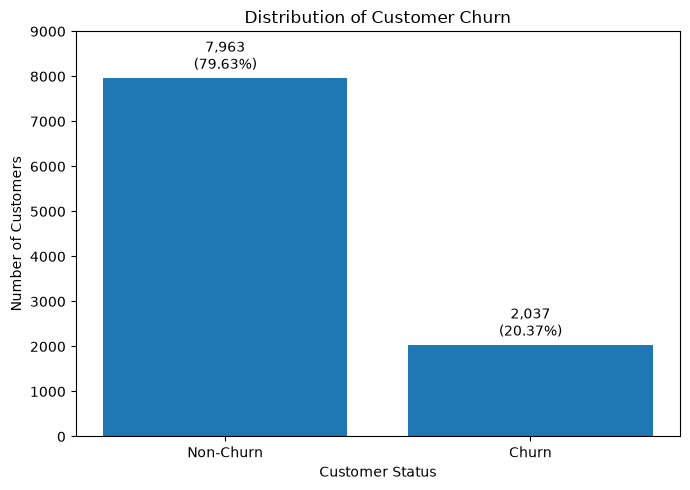

In [26]:
# Churn distribution
churn_counts = df["churn"].value_counts().sort_index()
churn_percentages = df["churn"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ["Non-Churn", "Churn"],
    churn_counts.values
)

ax.set_title("Distribution of Customer Churn")
ax.set_xlabel("Customer Status")
ax.set_ylabel("Number of Customers")

# Add count and percentage labels
for bar, count, percentage in zip(
    bars,
    churn_counts.values,
    churn_percentages.values
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom"
    )

# Add extra space above bars
ax.set_ylim(0, 9000)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Churn Distribution Findings

The dataset contains 7,963 non-churners (79.63%) and 2,037 churners (20.37%), showing a clear imbalance towards the non-churn class. Although the minority churn class remains sufficiently represented for modelling, the imbalance could cause classifiers to favour the majority class. Therefore, model performance will be assessed using metrics including precision, recall, F1-score and ROC-AUC rather than relying on accuracy alone. The effect of class-imbalance treatments will also be investigated during model development.

### 6.2.2 Numerical Variables and Churn

Numerical customer characteristics were compared between churners and non-churners to identify variables that may show an association with customer attrition. Mean and median values were examined for the main continuous and ordinal variables.

In [27]:
# Numerical variables to examine
numerical_vars = [
    "credit_score",
    "age",
    "tenure",
    "balance",
    "products_number",
    "estimated_salary"
]

# Compare mean and median values by churn status
numerical_churn_summary = (
    df.groupby("churn")[numerical_vars]
      .agg(["mean", "median"])
      .round(2)
)

numerical_churn_summary

credit_score           age        tenure          balance             \
              mean median   mean median   mean median      mean     median   
churn                                                                        
0           651.85  653.0  37.41   36.0   5.03    5.0  72745.30   92072.68   
1           645.35  646.0  44.84   45.0   4.93    5.0  91108.54  109349.29   

      products_number        estimated_salary             
                 mean median             mean     median  
churn                                                     
0                1.54    2.0         99738.39   99645.04  
1                1.48    1.0        101465.68  102460.84

In [28]:
# Churn rate by number of products
product_churn = (
    df.groupby("products_number")["churn"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "customers",
          "sum": "churners",
          "mean": "churn_rate"
      })
)

product_churn["churn_rate"] = (
    product_churn["churn_rate"] * 100
).round(2)

product_churn

,customers,churners,churn_rate
products_number,,,
1,5084,1409,27.71
2,4590,348,7.58
3,266,220,82.71
4,60,60,100.00


#### Numerical Variable Findings

Initial comparison between churners and non-churners shows that age and account balance display the clearest differences. Churners were older on average (44.84 years compared with 37.41 years for non-churners) and held a higher average account balance (91,108.54 compared with 72,745.30). In comparison, credit score, tenure and estimated salary showed relatively small differences between the two groups.

Product ownership showed a notable non-linear relationship with churn. Customers holding two products had the lowest observed churn rate (7.58%), compared with 27.71% among customers holding one product. Churn rates increased substantially among customers holding three (82.71%) and four (100%) products. However, the three and four product groups contain considerably fewer customers, with only 266 and 60 observations respectively, and these high churn rates should therefore be interpreted cautiously.

These findings suggest that examining mean values alone may hide important relationships between customer characteristics and churn. Further visual analysis will therefore be used to examine the distributions of age, balance and product ownership.

### 6.2.3 Age and Churn

Age showed one of the clearest differences between churners and non-churners during the initial numerical comparison. The distribution of age was therefore examined in greater detail to determine how churn varies across different age groups.

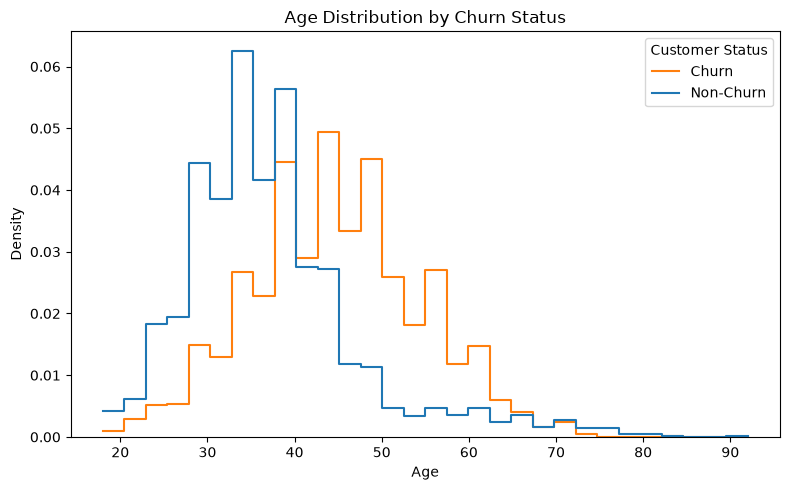

In [5]:
# Compare age distribution by churn status
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    hue="churn",
    bins=30,
    stat="density",
    common_norm=False,
    element="step",
    fill=False
)

plt.title("Age Distribution by Churn Status")
plt.xlabel("Age")
plt.ylabel("Density")

plt.legend(
    title="Customer Status",
    labels=["Churn", "Non-Churn"]
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/age_distribution_by_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
# Create age groups for exploratory analysis
age_bins = [18, 30, 40, 50, 60, 70, 100]
age_labels = [
    "18-29",
    "30-39",
    "40-49",
    "50-59",
    "60-69",
    "70+"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

age_churn = (
    df.groupby("age_group", observed=False)["churn"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "customers",
          "sum": "churners",
          "mean": "churn_rate"
      })
)

age_churn["churn_rate"] = (
    age_churn["churn_rate"] * 100
).round(2)

age_churn

,customers,churners,churn_rate
age_group,,,
18-29,1641,124,7.56
30-39,4346,473,10.88
40-49,2618,806,30.79
50-59,869,487,56.04
60-69,375,132,35.20
70+,151,15,9.93


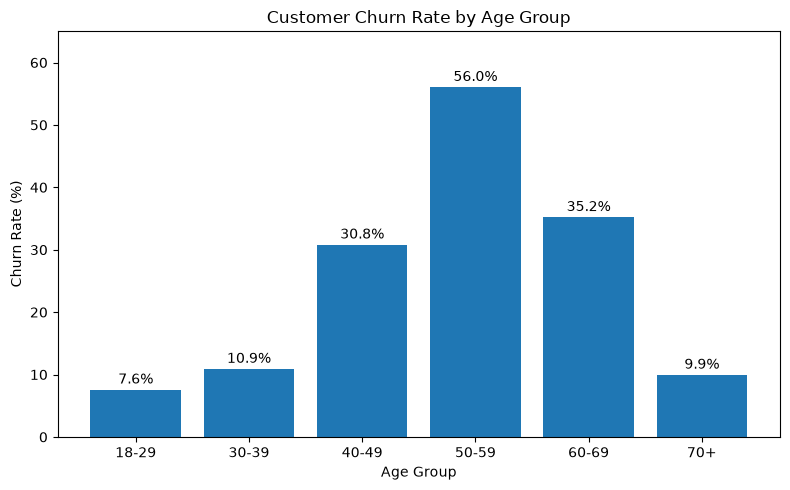

In [7]:
# Churn rate by age group
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    age_churn.index.astype(str),
    age_churn["churn_rate"]
)

ax.set_title("Customer Churn Rate by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Churn Rate (%)")

for bar, rate in zip(bars, age_churn["churn_rate"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{rate:.1f}%",
        ha="center"
    )

ax.set_ylim(0, 65)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/churn_rate_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Age and Churn Findings

Age shows a clear non-linear relationship with customer churn. Churn rates increase from 7.56% among customers aged 18–29 and 10.88% among those aged 30–39 to 30.79% for customers aged 40–49. The highest observed churn rate occurs among customers aged 50–59, at 56.04%, before declining to 35.20% for customers aged 60–69 and 9.93% among those aged 70 and above.

The age distributions also show that churners are concentrated at older ages than non-churners, consistent with the earlier finding that churners have a higher mean age. However, the decline in churn among the oldest groups demonstrates that the relationship is not simply linear. The 70+ group also contains only 151 customers, so its observed churn rate should be interpreted cautiously.

### 6.2.4 Account Balance and Churn

Account balance is an important variable within the proposed framework because it contributes to the baseline Customer Value measure while also representing a potential predictor of churn. Initial inspection identified a substantial number of customers with zero balances. The relationship between account balance and churn was therefore examined by distinguishing between zero-balance and positive-balance customers before analysing the distribution of positive balances.

In [8]:
# Create zero-balance indicator for exploratory analysis
df["zero_balance"] = df["balance"] == 0

balance_status_churn = (
    df.groupby("zero_balance")["churn"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "customers",
          "sum": "churners",
          "mean": "churn_rate"
      })
)

balance_status_churn["churn_rate"] = (
    balance_status_churn["churn_rate"] * 100
).round(2)

balance_status_churn.index = ["Positive Balance", "Zero Balance"]

balance_status_churn

,customers,churners,churn_rate
Positive Balance,6383,1537,24.08
Zero Balance,3617,500,13.82


In [9]:
# Positive-balance customers only
positive_balance = df[df["balance"] > 0]

positive_balance_summary = (
    positive_balance.groupby("churn")["balance"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

positive_balance_summary

,count,mean,median,std
churn,,,,
0,4846,119535.86,119791.22,29944.93
1,1537,120746.97,119948.09,30555.19


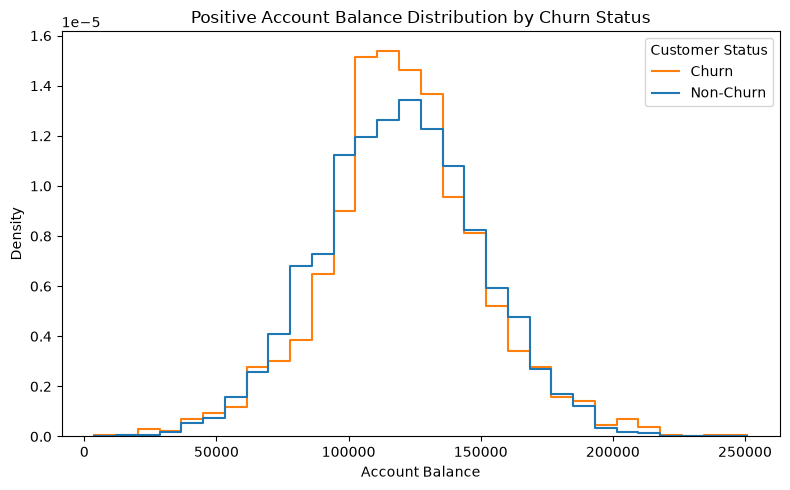

In [10]:
# Positive account balance distribution by churn status
plt.figure(figsize=(8, 5))

sns.histplot(
    data=positive_balance,
    x="balance",
    hue="churn",
    bins=30,
    stat="density",
    common_norm=False,
    element="step",
    fill=False
)

plt.title("Positive Account Balance Distribution by Churn Status")
plt.xlabel("Account Balance")
plt.ylabel("Density")

plt.legend(
    title="Customer Status",
    labels=["Churn", "Non-Churn"]
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/positive_balance_distribution_by_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Key findings

Customers with a positive account balance had a substantially higher churn rate (24.08%) than customers with a zero balance (13.82%). However, among customers with positive balances, the balance distributions of churners and non-churners were very similar. Churners had a mean balance of approximately 120,747 compared with 119,536 for non-churners, while the median balances were almost identical at approximately 119,948 and 119,791 respectively.

This indicates that the large difference in overall mean balance previously observed between churners and non-churners is influenced considerably by the presence of zero-balance customers, rather than by churners consistently holding much larger positive balances. Therefore, the relationship between balance and churn appears to be associated more strongly with whether a customer holds a positive balance than with the magnitude of the balance itself.

### 6.2.5 Product Ownership and Churn

Product ownership is one of the two financial variables proposed for the baseline Customer Value calculation. Its relationship with churn is therefore examined before constructing the baseline CV measure.

In [5]:
# Churn rate by number of products
product_churn = (
    df.groupby("products_number")["churn"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "customers",
          "sum": "churners",
          "mean": "churn_rate"
      })
)

product_churn["churn_rate"] = product_churn["churn_rate"] * 100

product_churn

,customers,churners,churn_rate
products_number,,,
1,5084,1409,27.714398
2,4590,348,7.581699
3,266,220,82.706767
4,60,60,100.000000


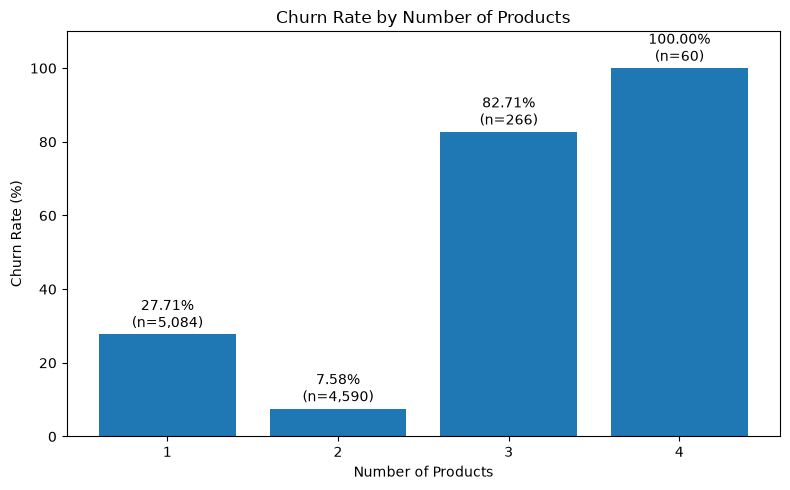

In [6]:
# Plot churn rate by number of products
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    product_churn.index.astype(str),
    product_churn["churn_rate"]
)

ax.set_title("Churn Rate by Number of Products")
ax.set_xlabel("Number of Products")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, 110)

# Add churn rate and group size to each bar
for bar, (_, row) in zip(bars, product_churn.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f'{row["churn_rate"]:.2f}%\n(n={int(row["customers"]):,})',
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "../outputs/figures/churn_rate_by_number_of_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
# Customer characteristics by number of products
product_profile = (
    df.groupby("products_number")
      .agg(
          customers=("customer_id", "count"),
          churn_rate=("churn", "mean"),
          mean_age=("age", "mean"),
          mean_balance=("balance", "mean"),
          median_balance=("balance", "median"),
          active_rate=("active_member", "mean"),
          credit_card_rate=("credit_card", "mean"),
          mean_tenure=("tenure", "mean")
      )
)

product_profile["churn_rate"] *= 100
product_profile["active_rate"] *= 100
product_profile["credit_card_rate"] *= 100

product_profile.round(2)

,customers,churn_rate,mean_age,mean_balance,median_balance,active_rate,credit_card_rate,mean_tenure
products_number,,,,,,,,
1,5084,27.71,39.67,98551.87,111886.04,50.41,70.38,4.97
2,4590,7.58,37.75,51879.15,0.00,53.29,70.72,5.05
3,266,82.71,43.20,75458.33,95973.94,42.48,71.43,5.00
4,60,100.00,45.68,93733.14,116808.20,48.33,68.33,5.30


#### Key findings

Product ownership shows a strong non-linear relationship with customer churn. Customers holding two products had the lowest churn rate at 7.58%, compared with 27.71% among customers holding one product. Churn increased substantially among customers with three products, reaching 82.71%, while all 60 customers holding four products had churned.

The three and four product groups are considerably smaller than the one and two product groups, so the extreme churn rates should be interpreted with caution. Customers with three or four products were also older on average and had somewhat lower active membership rates, although average tenure and credit-card ownership were relatively similar across the product groups.

Balance also varied considerably by product ownership. In particular, customers holding two products had a median balance of zero despite having the lowest churn rate. Overall, the results indicate that the relationship between product ownership and churn is not linear, and that greater product ownership should not automatically be interpreted as indicating greater customer retention.

### 6.2.6 Active Membership and Churn

Active membership represents a behavioural characteristic of the customer relationship and is therefore examined as a potential predictor of churn.

In [14]:
# Churn by active membership status
active_churn = (
    df.groupby("active_member")["churn"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "customers",
          "sum": "churners",
          "mean": "churn_rate"
      })
)

active_churn["churn_rate"] = active_churn["churn_rate"] * 100

# Rename categories for readability
active_churn.index = active_churn.index.map({
    0: "Inactive",
    1: "Active"
})

active_churn.round(2)

,customers,churners,churn_rate
active_member,,,
Inactive,4849,1302,26.85
Active,5151,735,14.27


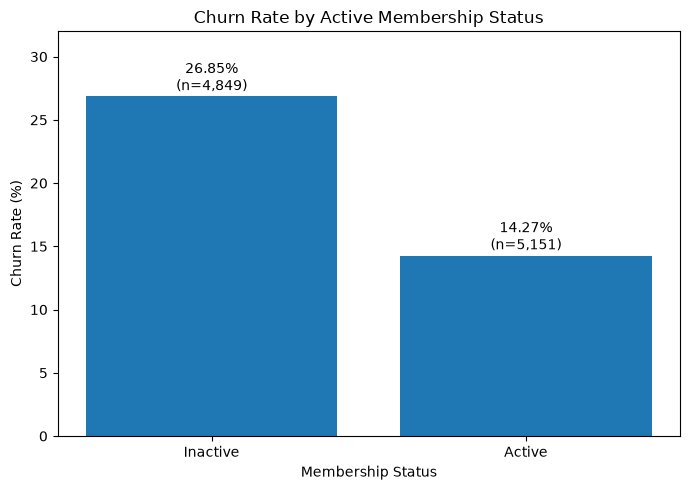

In [17]:
# Plot churn rate by active membership
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    active_churn.index,
    active_churn["churn_rate"]
)

ax.set_title("Churn Rate by Active Membership Status")
ax.set_xlabel("Membership Status")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, 32)

# Add churn rate and group size above each bar
for bar, (_, row) in zip(bars, active_churn.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{row["churn_rate"]:.2f}%\n(n={int(row["customers"]):,})',
        ha="center"
    )

plt.tight_layout()
plt.show()

In [16]:
# Churn rate by age group and active membership
age_active_churn = (
    df.groupby(["age_group", "active_member"], observed=True)["churn"]
      .agg(["count", "mean"])
      .rename(columns={
          "count": "customers",
          "mean": "churn_rate"
      })
)

age_active_churn["churn_rate"] *= 100

age_active_churn.round(2)

customers  churn_rate
age_group active_member                       
18-29     0                    804        9.83
          1                    837        5.38
30-39     0                   2165       13.63
          1                   2181        8.16
40-49     0                   1396       37.97
          1                   1222       22.59
50-59     0                    373       81.23
          1                    496       37.10
60-69     0                     94       91.49
          1                    281       16.37
70+       0                     17       52.94
          1                    134        4.48

#### Key findings

Active membership shows a clear relationship with customer churn. Inactive customers had a churn rate of 26.85%, compared with 14.27% among active customers.

The difference remained when customers were compared within age groups, with active customers consistently showing lower churn rates. The difference was particularly pronounced among older customers. For example, among customers aged 50–59, the churn rate was 81.23% for inactive customers compared with 37.10% for active customers. Among customers aged 60–69, the corresponding rates were 91.49% and 16.37%.

These results suggest that active membership may provide useful information for churn prediction and that its relationship with churn may also vary with customer age. However, the results are descriptive and do not establish that active membership itself causes lower churn.

### 6.2.7 Country and Gender

Country and gender are examined to determine whether churn rates differ across the demographic groups represented within the dataset.

In [18]:
# Churn by country
country_churn = (
    df.groupby("country")["churn"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "customers",
          "sum": "churners",
          "mean": "churn_rate"
      })
)

country_churn["churn_rate"] *= 100
country_churn.round(2)

,customers,churners,churn_rate
country,,,
France,5014,810,16.15
Germany,2509,814,32.44
Spain,2477,413,16.67


In [19]:
# Churn by gender
gender_churn = (
    df.groupby("gender")["churn"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "customers",
          "sum": "churners",
          "mean": "churn_rate"
      })
)

gender_churn["churn_rate"] *= 100
gender_churn.round(2)

,customers,churners,churn_rate
gender,,,
Female,4543,1139,25.07
Male,5457,898,16.46


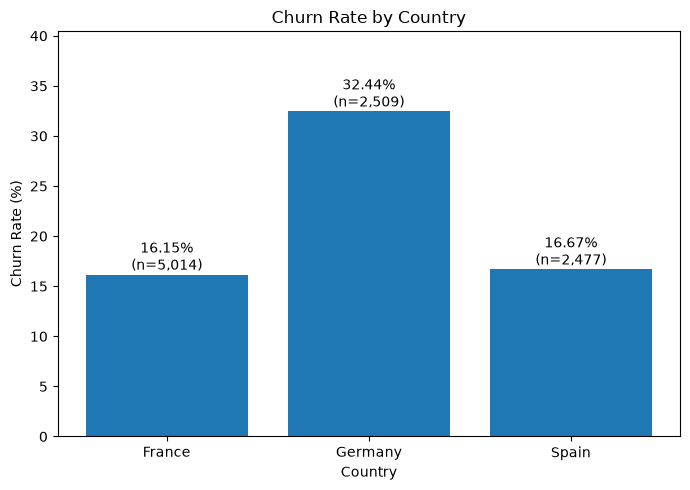

In [20]:
# Plot churn rate by country
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    country_churn.index,
    country_churn["churn_rate"]
)

ax.set_title("Churn Rate by Country")
ax.set_xlabel("Country")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, country_churn["churn_rate"].max() + 8)

for bar, (_, row) in zip(bars, country_churn.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{row["churn_rate"]:.2f}%\n(n={int(row["customers"]):,})',
        ha="center"
    )

plt.tight_layout()
plt.show()

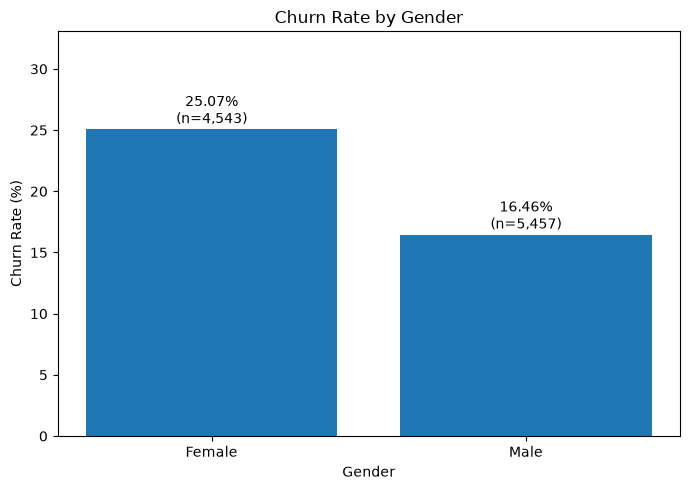

In [21]:
# Plot churn rate by gender
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    gender_churn.index,
    gender_churn["churn_rate"]
)

ax.set_title("Churn Rate by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, gender_churn["churn_rate"].max() + 8)

for bar, (_, row) in zip(bars, gender_churn.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{row["churn_rate"]:.2f}%\n(n={int(row["customers"]):,})',
        ha="center"
    )

plt.tight_layout()
plt.show()

In [22]:
# Customer characteristics by country
country_profile = (
    df.groupby("country")
      .agg(
          customers=("customer_id", "count"),
          churn_rate=("churn", "mean"),
          mean_age=("age", "mean"),
          mean_balance=("balance", "mean"),
          mean_products=("products_number", "mean"),
          active_rate=("active_member", "mean")
      )
)

country_profile["churn_rate"] *= 100
country_profile["active_rate"] *= 100

country_profile.round(2)

,customers,churn_rate,mean_age,mean_balance,mean_products,active_rate
country,,,,,,
France,5014,16.15,38.51,62092.64,1.53,51.68
Germany,2509,32.44,39.77,119730.12,1.52,49.74
Spain,2477,16.67,38.89,61818.15,1.54,52.97


#### Key findings

Churn rates varied considerably by country. Customers in Germany had the highest churn rate at 32.44%, compared with 16.15% in France and 16.67% in Spain. German customers also had a substantially higher mean account balance, at approximately 119,730 compared with approximately 62,093 in France and 61,818 in Spain. Average age, product ownership and active membership were relatively similar across the three countries. These results indicate that country may provide useful information for churn prediction, although the descriptive analysis does not establish the reasons for the higher churn rate among German customers.

Gender also showed a difference in churn behaviour. Female customers had a churn rate of 25.07%, compared with 16.46% among male customers. Gender will therefore be retained as a potential predictor for the churn modelling stage, where its contribution can be assessed alongside the other customer characteristics.

### 6.2.8 Remaining Churn Predictors

Credit score, tenure, estimated salary and credit-card ownership are also examined as potential predictors of customer churn. These variables are assessed together to determine whether they show meaningful differences between churners and non-churners.

In [23]:
# Summary of remaining numerical variables by churn status
remaining_numerical = (
    df.groupby("churn")[
        ["credit_score", "tenure", "estimated_salary"]
    ]
    .agg(["mean", "median", "std"])
    .round(2)
)

remaining_numerical

credit_score                tenure              estimated_salary  \
              mean median     std   mean median   std             mean   
churn                                                                    
0           651.85  653.0   95.65   5.03    5.0  2.88         99738.39   
1           645.35  646.0  100.32   4.93    5.0  2.94        101465.68   

                            
          median       std  
churn                       
0       99645.04  57405.59  
1      102460.84  57912.42

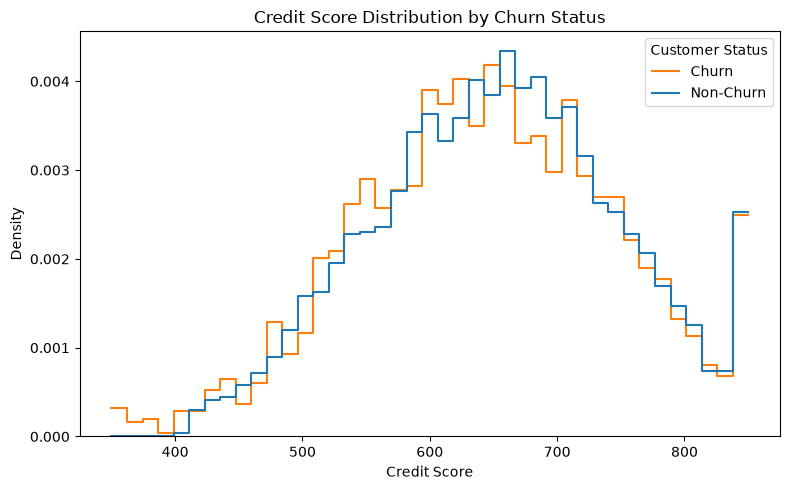

In [24]:
# Credit score distribution by churn status
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="credit_score",
    hue="churn",
    stat="density",
    common_norm=False,
    element="step",
    fill=False
)

plt.title("Credit Score Distribution by Churn Status")
plt.xlabel("Credit Score")
plt.ylabel("Density")

plt.legend(
    title="Customer Status",
    labels=["Churn", "Non-Churn"]
)

plt.tight_layout()
plt.show()

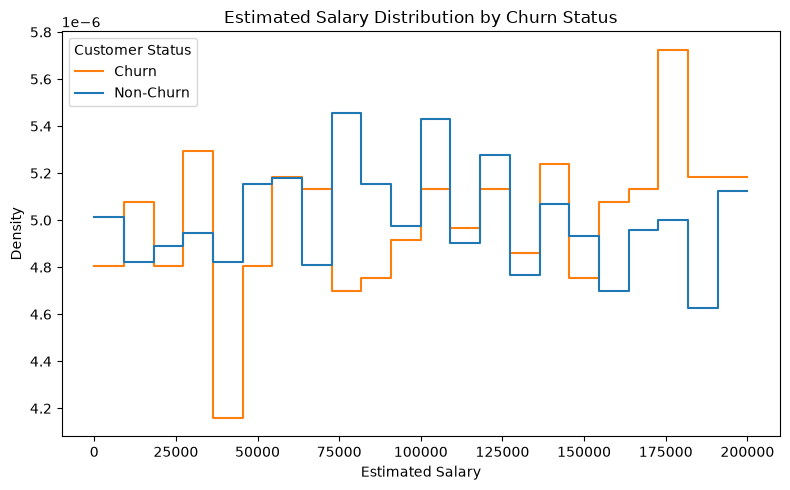

In [25]:
# Estimated salary distribution by churn status
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="estimated_salary",
    hue="churn",
    stat="density",
    common_norm=False,
    element="step",
    fill=False
)

plt.title("Estimated Salary Distribution by Churn Status")
plt.xlabel("Estimated Salary")
plt.ylabel("Density")

plt.legend(
    title="Customer Status",
    labels=["Churn", "Non-Churn"]
)

plt.tight_layout()
plt.show()

In [26]:
# Churn rate by tenure
tenure_churn = (
    df.groupby("tenure")["churn"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "customers",
          "sum": "churners",
          "mean": "churn_rate"
      })
)

tenure_churn["churn_rate"] *= 100

tenure_churn.round(2)

,customers,churners,churn_rate
tenure,,,
0,413,95,23.00
1,1035,232,22.42
2,1048,201,19.18
3,1009,213,21.11
4,989,203,20.53
5,1012,209,20.65
6,967,196,20.27
7,1028,177,17.22
8,1025,197,19.22


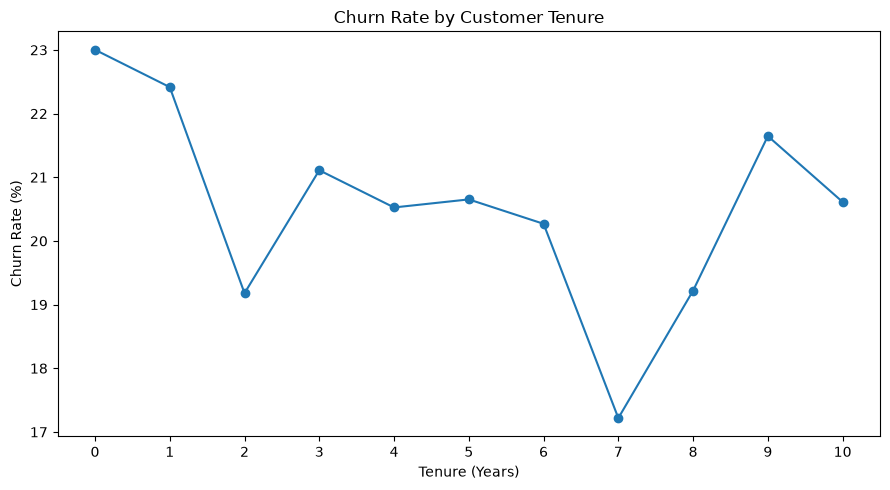

In [27]:
# Plot churn rate by tenure
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    tenure_churn.index,
    tenure_churn["churn_rate"],
    marker="o"
)

ax.set_title("Churn Rate by Customer Tenure")
ax.set_xlabel("Tenure (Years)")
ax.set_ylabel("Churn Rate (%)")
ax.set_xticks(tenure_churn.index)

plt.tight_layout()
plt.show()

In [28]:
# Churn by credit-card ownership
credit_card_churn = (
    df.groupby("credit_card")["churn"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "customers",
          "sum": "churners",
          "mean": "churn_rate"
      })
)

credit_card_churn["churn_rate"] *= 100

credit_card_churn.index = credit_card_churn.index.map({
    0: "No Credit Card",
    1: "Credit Card"
})

credit_card_churn.round(2)

,customers,churners,churn_rate
credit_card,,,
No Credit Card,2945,613,20.81
Credit Card,7055,1424,20.18


#### Key findings

Credit score showed only a small difference between churners and non-churners, with mean scores of 645.35 and 651.85 respectively. The substantial overlap between the distributions suggests that credit score has a relatively weak standalone relationship with churn.

Estimated salary also showed little separation between the two groups. Churners had a slightly higher mean estimated salary (£101,465.68) than non-churners (£99,738.39), but the distributions were broadly similar.

Customer tenure did not demonstrate a clear linear relationship with churn. Churn rates varied across tenure levels, ranging from 17.22% at seven years to 23.00% among customers with zero years of tenure, while mean tenure was similar for churners and non-churners. These variables will therefore be retained as potential predictors, as weak individual relationships do not rule out predictive value when considered alongside other customer characteristics.

Credit-card ownership showed very little difference in churn behaviour. Customers without a credit card had a churn rate of 20.81%, compared with 20.18% among customers with a credit card. This suggests that credit-card ownership has a weak standalone relationship with customer churn, although the variable will be retained for the modelling stage to determine whether it contributes predictive information when considered alongside other customer characteristics.

## Data Preprocessing and Model Preparation

Following exploratory analysis, the data is prepared for machine learning. The target variable is separated from the predictor variables and the customer identifier is excluded because it does not represent a meaningful customer characteristic.

An 80/20 stratified train-test split is used to preserve the proportion of churners and non-churners in both datasets. All subsequent preprocessing and model development will be fitted using the training data to prevent information from the test set leaking into the modelling process.

In [31]:
from sklearn.model_selection import train_test_split

# Separate predictors and target
X = df.drop(columns=["churn", "customer_id"])
y = df["churn"]

# Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining churn distribution:")
print(y_train.value_counts())
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest churn distribution:")
print(y_test.value_counts())
print((y_test.value_counts(normalize=True) * 100).round(2))

Training set: (8000, 10)
Test set: (2000, 10)

Training churn distribution:
churn
0    6370
1    1630
Name: count, dtype: int64
churn
0    79.62
1    20.38
Name: proportion, dtype: float64

Test churn distribution:
churn
0    1593
1     407
Name: count, dtype: int64
churn
0    79.65
1    20.35
Name: proportion, dtype: float64


#### Train-Test Split Observation

The stratified split produced 8,000 training observations and 2,000 testing observations. The churn distribution was preserved across both datasets, with churners representing 20.38% of the training set and 20.35% of the test set, closely matching the 20.37% churn rate in the full dataset. The test set will remain separate during model development and will only be used for final model evaluation.

### Preprocessing Pipeline

The predictor variables require different preprocessing according to their data type. `country` and `gender` are categorical variables and will therefore be one-hot encoded. The continuous and ordinal numerical variables will be standardised, while the existing binary variables `credit_card` and `active_member` will be retained in their original 0/1 form.

Preprocessing is incorporated into the modelling pipeline rather than being applied to the complete dataset in advance. This ensures that transformations are learned only from the relevant training data during model development and cross-validation, reducing the risk of data leakage.

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define variable groups
categorical_features = [
    "country",
    "gender"
]

numerical_features = [
    "credit_score",
    "age",
    "tenure",
    "balance",
    "products_number",
    "estimated_salary"
]

binary_features = [
    "credit_card",
    "active_member"
]

# Create preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ]
)

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)
print("Binary features:", binary_features)

Categorical features: ['country', 'gender']
Numerical features: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']
Binary features: ['credit_card', 'active_member']


In [33]:
# Sanity check preprocessing on training data only
X_train_processed = preprocessor.fit_transform(X_train)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

Original training shape: (8000, 10)
Processed training shape: (8000, 13)


In [34]:
feature_names = preprocessor.get_feature_names_out()

feature_names

array(['categorical__country_France', 'categorical__country_Germany',
       'categorical__country_Spain', 'categorical__gender_Female',
       'categorical__gender_Male', 'numerical__credit_score',
       'numerical__age', 'numerical__tenure', 'numerical__balance',
       'numerical__products_number', 'numerical__estimated_salary',
       'binary__credit_card', 'binary__active_member'], dtype=object)

#### Preprocessing Check

The preprocessing transformer successfully converted the 10 original predictor variables into 13 model ready features. The categorical variables were expanded through one-hot encoding, numerical variables were standardised, and the existing binary variables were retained in their original form. The transformation was fitted to the training data only as an initial validation of the preprocessing design. During model development, preprocessing will be incorporated directly within each modelling pipeline to prevent data leakage during cross-validation.

## Churn Prediction Modelling

### Baseline Logistic Regression Model

Logistic Regression is used as the initial baseline classifier against which the more complex machine learning models can be compared. The preprocessing transformer is incorporated directly within the modelling pipeline so that preprocessing is fitted independently within each training fold during cross-validation.

Model performance is evaluated using stratified 5-fold cross-validation. Accuracy, precision, recall, F1-score and ROC-AUC are recorded to provide a balanced assessment of predictive performance, particularly given the class imbalance identified during exploratory analysis.

In [35]:
# Baseline Logistic Regression with stratified 5-fold cross-validation

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

# Create Logistic Regression pipeline
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Stratified 5-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Evaluation metrics
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

# Perform cross-validation using training data only
logistic_cv_results = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

# Summarise cross-validation results
logistic_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Mean CV Score": [
        logistic_cv_results["test_accuracy"].mean(),
        logistic_cv_results["test_precision"].mean(),
        logistic_cv_results["test_recall"].mean(),
        logistic_cv_results["test_f1"].mean(),
        logistic_cv_results["test_roc_auc"].mean()
    ],
    "Standard Deviation": [
        logistic_cv_results["test_accuracy"].std(),
        logistic_cv_results["test_precision"].std(),
        logistic_cv_results["test_recall"].std(),
        logistic_cv_results["test_f1"].std(),
        logistic_cv_results["test_roc_auc"].std()
    ]
})

# Format results
logistic_summary["Mean CV Score"] = logistic_summary["Mean CV Score"].round(4)
logistic_summary["Standard Deviation"] = logistic_summary["Standard Deviation"].round(4)

logistic_summary

,Metric,Mean CV Score,Standard Deviation
0,Accuracy,0.8104,0.0066
1,Precision,0.5961,0.0440
2,Recall,0.2135,0.0249
3,F1-score,0.3141,0.0317
4,ROC-AUC,0.7628,0.0199


#### Baseline Logistic Regression Results

The baseline Logistic Regression model achieved a mean cross-validation accuracy of 81.04% and ROC-AUC of 0.7628. However, recall was substantially lower at 21.35%, indicating that the model failed to identify a large proportion of customers who actually churned. The relatively high accuracy should therefore be interpreted cautiously given the imbalance in the target variable.

Precision was 59.61%, while the combined precision-recall performance produced an F1-score of 0.3141. The results provide an initial benchmark against which more complex classification models and subsequent class-imbalance treatments can be evaluated.

#### Baseline Decision Tree Model

In [36]:
# Baseline Decision Tree with stratified 5-fold cross-validation

from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree pipeline
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=42
        ))
    ]
)

# Perform cross-validation using the same folds and metrics
decision_tree_cv_results = cross_validate(
    decision_tree_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

# Summarise cross-validation results
decision_tree_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Mean CV Score": [
        decision_tree_cv_results["test_accuracy"].mean(),
        decision_tree_cv_results["test_precision"].mean(),
        decision_tree_cv_results["test_recall"].mean(),
        decision_tree_cv_results["test_f1"].mean(),
        decision_tree_cv_results["test_roc_auc"].mean()
    ],
    "Standard Deviation": [
        decision_tree_cv_results["test_accuracy"].std(),
        decision_tree_cv_results["test_precision"].std(),
        decision_tree_cv_results["test_recall"].std(),
        decision_tree_cv_results["test_f1"].std(),
        decision_tree_cv_results["test_roc_auc"].std()
    ]
})

decision_tree_summary["Mean CV Score"] = (
    decision_tree_summary["Mean CV Score"].round(4)
)

decision_tree_summary["Standard Deviation"] = (
    decision_tree_summary["Standard Deviation"].round(4)
)

decision_tree_summary

,Metric,Mean CV Score,Standard Deviation
0,Accuracy,0.7860,0.0028
1,Precision,0.4760,0.0062
2,Recall,0.4988,0.0326
3,F1-score,0.4866,0.0170
4,ROC-AUC,0.6791,0.0122


#### Baseline Decision Tree Results

The baseline Decision Tree achieved a mean cross-validation accuracy of 78.60% and ROC-AUC of 0.6791. Recall increased substantially to 49.88% compared with the baseline Logistic Regression model, indicating that the Decision Tree identified a greater proportion of customers who churned. The F1-score also increased to 0.4866.

However, this improvement was accompanied by lower precision, accuracy and ROC-AUC. The results therefore demonstrate a trade-off between identifying more churners and overall classification performance. Further optimisation will be required before determining whether the Decision Tree provides a suitable churn model.

### Baseline Random Forest Model

A Random Forest classifier is evaluated as an ensemble alternative to the individual Decision Tree. By combining predictions across multiple decision trees, Random Forest may capture non-linear relationships while reducing the instability and overfitting associated with a single tree.

In [37]:
# Baseline Random Forest with stratified 5-fold cross-validation

from sklearn.ensemble import RandomForestClassifier

# Create Random Forest pipeline
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("classifier", RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Perform cross-validation
random_forest_cv_results = cross_validate(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

# Summarise cross-validation results
random_forest_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Mean CV Score": [
        random_forest_cv_results["test_accuracy"].mean(),
        random_forest_cv_results["test_precision"].mean(),
        random_forest_cv_results["test_recall"].mean(),
        random_forest_cv_results["test_f1"].mean(),
        random_forest_cv_results["test_roc_auc"].mean()
    ],
    "Standard Deviation": [
        random_forest_cv_results["test_accuracy"].std(),
        random_forest_cv_results["test_precision"].std(),
        random_forest_cv_results["test_recall"].std(),
        random_forest_cv_results["test_f1"].std(),
        random_forest_cv_results["test_roc_auc"].std()
    ]
})

random_forest_summary["Mean CV Score"] = (
    random_forest_summary["Mean CV Score"].round(4)
)

random_forest_summary["Standard Deviation"] = (
    random_forest_summary["Standard Deviation"].round(4)
)

random_forest_summary

,Metric,Mean CV Score,Standard Deviation
0,Accuracy,0.8574,0.0091
1,Precision,0.7480,0.0334
2,Recall,0.4521,0.0311
3,F1-score,0.5633,0.0318
4,ROC-AUC,0.8452,0.0127


#### Baseline Random Forest Results

The baseline Random Forest produced the strongest overall performance of the models evaluated so far, achieving a mean cross-validation accuracy of 85.74%, precision of 74.80%, F1-score of 0.5633 and ROC-AUC of 0.8452. Recall was 45.21%, which was slightly lower than the individual Decision Tree but substantially higher than Logistic Regression.

The results indicate that the ensemble model provides a stronger balance between identifying churners and overall discriminatory performance. The relatively small variation across the five folds also suggests that performance is reasonably stable. However, further comparison with Gradient Boosting and subsequent optimisation is required before selecting the final churn model.

### Baseline Gradient Boosting Model

Gradient Boosting is evaluated as the final baseline classification model. Unlike Random Forest, which combines independently constructed trees, Gradient Boosting builds trees sequentially, with each new tree attempting to improve errors made by the preceding ensemble. This allows the model to capture complex and non-linear relationships within the customer data.

In [38]:
# Baseline Gradient Boosting with stratified 5-fold cross-validation

from sklearn.ensemble import GradientBoostingClassifier

# Create Gradient Boosting pipeline
gradient_boosting_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("classifier", GradientBoostingClassifier(
            random_state=42
        ))
    ]
)

# Perform cross-validation
gradient_boosting_cv_results = cross_validate(
    gradient_boosting_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

# Summarise cross-validation results
gradient_boosting_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Mean CV Score": [
        gradient_boosting_cv_results["test_accuracy"].mean(),
        gradient_boosting_cv_results["test_precision"].mean(),
        gradient_boosting_cv_results["test_recall"].mean(),
        gradient_boosting_cv_results["test_f1"].mean(),
        gradient_boosting_cv_results["test_roc_auc"].mean()
    ],
    "Standard Deviation": [
        gradient_boosting_cv_results["test_accuracy"].std(),
        gradient_boosting_cv_results["test_precision"].std(),
        gradient_boosting_cv_results["test_recall"].std(),
        gradient_boosting_cv_results["test_f1"].std(),
        gradient_boosting_cv_results["test_roc_auc"].std()
    ]
})

gradient_boosting_summary["Mean CV Score"] = (
    gradient_boosting_summary["Mean CV Score"].round(4)
)

gradient_boosting_summary["Standard Deviation"] = (
    gradient_boosting_summary["Standard Deviation"].round(4)
)

gradient_boosting_summary

,Metric,Mean CV Score,Standard Deviation
0,Accuracy,0.8631,0.0085
1,Precision,0.7726,0.0279
2,Recall,0.4644,0.0298
3,F1-score,0.5800,0.0306
4,ROC-AUC,0.8640,0.0094


#### Baseline Gradient Boosting Results

Gradient Boosting achieved the strongest overall baseline performance, with a mean cross-validation accuracy of 86.31%, precision of 77.26%, F1-score of 0.5800 and ROC-AUC of 0.8640. Recall was 46.44%, indicating that fewer than half of actual churners were identified at the default classification threshold.

Compared with the other baseline models, Gradient Boosting provided the strongest overall balance of predictive performance. However, the moderate recall and previously identified class imbalance indicate that imbalance-handling approaches should be investigated before final model selection.

In [39]:
# Combine baseline model cross-validation results

baseline_comparison = pd.DataFrame({
    "Logistic Regression": {
        "Accuracy": logistic_cv_results["test_accuracy"].mean(),
        "Precision": logistic_cv_results["test_precision"].mean(),
        "Recall": logistic_cv_results["test_recall"].mean(),
        "F1-score": logistic_cv_results["test_f1"].mean(),
        "ROC-AUC": logistic_cv_results["test_roc_auc"].mean()
    },
    "Decision Tree": {
        "Accuracy": decision_tree_cv_results["test_accuracy"].mean(),
        "Precision": decision_tree_cv_results["test_precision"].mean(),
        "Recall": decision_tree_cv_results["test_recall"].mean(),
        "F1-score": decision_tree_cv_results["test_f1"].mean(),
        "ROC-AUC": decision_tree_cv_results["test_roc_auc"].mean()
    },
    "Random Forest": {
        "Accuracy": random_forest_cv_results["test_accuracy"].mean(),
        "Precision": random_forest_cv_results["test_precision"].mean(),
        "Recall": random_forest_cv_results["test_recall"].mean(),
        "F1-score": random_forest_cv_results["test_f1"].mean(),
        "ROC-AUC": random_forest_cv_results["test_roc_auc"].mean()
    },
    "Gradient Boosting": {
        "Accuracy": gradient_boosting_cv_results["test_accuracy"].mean(),
        "Precision": gradient_boosting_cv_results["test_precision"].mean(),
        "Recall": gradient_boosting_cv_results["test_recall"].mean(),
        "F1-score": gradient_boosting_cv_results["test_f1"].mean(),
        "ROC-AUC": gradient_boosting_cv_results["test_roc_auc"].mean()
    }
}).T.round(4)

baseline_comparison

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.8104,0.5961,0.2135,0.3141,0.7628
Decision Tree,0.7860,0.4760,0.4988,0.4866,0.6791
Random Forest,0.8574,0.7480,0.4521,0.5633,0.8452
Gradient Boosting,0.8631,0.7726,0.4644,0.5800,0.8640


#### Class Imbalance Handling Techniques

This will be performed on the Gradient Boosting model because it was the leading baseline model.

In [40]:
# Comparing class imbalance handling techniques for Gradient Boosting

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

# Stratified 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Scoring metrics
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

# Resampling approaches
sampling_methods = {
    "No Resampling": None,
    "Random Oversampling": RandomOverSampler(random_state=42),
    "Random Undersampling": RandomUnderSampler(random_state=42),
    "SMOTE": SMOTE(random_state=42)
}

imbalance_results = []

for method_name, sampler in sampling_methods.items():

    steps = [
        ("preprocessor", preprocessor)
    ]

    if sampler is not None:
        steps.append(("sampler", sampler))

    steps.append(
        ("classifier", GradientBoostingClassifier(random_state=42))
    )

    pipeline = ImbPipeline(steps=steps)

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    imbalance_results.append({
        "Method": method_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1-score": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

imbalance_comparison = (
    pd.DataFrame(imbalance_results)
    .set_index("Method")
    .round(4)
)

imbalance_comparison

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Method,,,,,
No Resampling,0.8631,0.7726,0.4644,0.5800,0.8640
Random Oversampling,0.8029,0.5115,0.7380,0.6038,0.8619
Random Undersampling,0.7896,0.4900,0.7552,0.5937,0.8596
SMOTE,0.8418,0.6062,0.6368,0.6205,0.8589


### Class Imbalance Comparison

Four approaches were compared using stratified 5-fold cross-validation: no resampling, random oversampling, random undersampling and SMOTE. The baseline Gradient Boosting model achieved the highest accuracy (86.31%) and ROC-AUC (0.8640), but recall was relatively low at 46.44%, indicating that a substantial proportion of churners were not identified.

Random oversampling and undersampling increased recall to 73.80% and 75.52%, respectively, but resulted in considerable reductions in precision and overall accuracy. SMOTE provided a more balanced trade-off, increasing recall to 63.68% while achieving the highest F1-score (0.6205) among the four approaches. SMOTE was therefore selected for subsequent model development, as identifying customers at risk of churn is particularly important within the proposed risk-adjusted Customer Value framework.

In [41]:
# Hyperparameter tuning for Gradient Boosting with SMOTE

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Pipeline ensures preprocessing and SMOTE occur within each training fold
gb_smote_pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

# Hyperparameter search space
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__max_depth": [2, 3, 4],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

# Grid search using stratified 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=gb_smote_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation F1-score:")
print(round(grid_search.best_score_, 4))

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters:
{'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}

Best cross-validation F1-score:
0.621


### Gradient Boosting Hyperparameter Optimisation

The Gradient Boosting model combined with SMOTE was optimised using grid search with stratified 5-fold cross-validation. The search evaluated 48 hyperparameter combinations, resulting in 240 model fits. F1-score was used as the optimisation metric to balance the model's ability to identify churners while limiting false-positive predictions.

The optimal configuration used 200 estimators, a learning rate of 0.1, maximum tree depth of 3, minimum samples per leaf of 1 and minimum samples required to split of 2. The tuned model achieved a mean cross-validation F1-score of 0.6210. This represented only a small improvement over the untuned SMOTE model (0.6205), suggesting that the baseline Gradient Boosting configuration was already performing close to the best configuration identified within the specified search space.

In [42]:
# Final evaluation of tuned Gradient Boosting model on the held-out test set

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Best model identified by GridSearchCV
final_model = grid_search.best_estimator_

# Generate predictions on the untouched test set
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_prob)

# Store results in a table
final_test_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Test Score": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_roc_auc
    ]
})

final_test_results["Test Score"] = (
    final_test_results["Test Score"].round(4)
)

print("Final Test-Set Performance")
display(final_test_results)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Non-Churn", "Churn"]
))

Final Test-Set Performance


,Metric,Test Score
0,Accuracy,0.8630
1,Precision,0.6928
2,Recall,0.5872
3,F1-score,0.6356
4,ROC-AUC,0.8718



Confusion Matrix
[[1487  106]
 [ 168  239]]

Classification Report
              precision    recall  f1-score   support

   Non-Churn       0.90      0.93      0.92      1593
       Churn       0.69      0.59      0.64       407

    accuracy                           0.86      2000
   macro avg       0.80      0.76      0.78      2000
weighted avg       0.86      0.86      0.86      2000



### Final Churn Model Evaluation

The optimised Gradient Boosting model was evaluated on the previously unseen test set containing 2,000 customers. The model achieved an accuracy of 86.30%, precision of 69.28%, recall of 58.72%, F1-score of 0.6356 and ROC-AUC of 0.8718.

The confusion matrix showed that 239 of the 407 customers who churned were correctly identified, while 168 churners were incorrectly classified as non-churners. The model also correctly identified 1,487 of the 1,593 non-churners, with 106 incorrectly classified as churners. The results therefore demonstrate a trade-off between identifying customers at risk of churn and limiting false-positive predictions.

The test F1-score and ROC-AUC were consistent with the performance observed during cross-validation, indicating that the selected model generalised reasonably well to unseen data. The ROC-AUC of 0.8718 also indicates that the model has a strong ability to distinguish between churners and non-churners. As the final framework requires individual churn probabilities rather than only binary classifications, the probability outputs from this model will subsequently be used within the churn risk-adjustment stage.

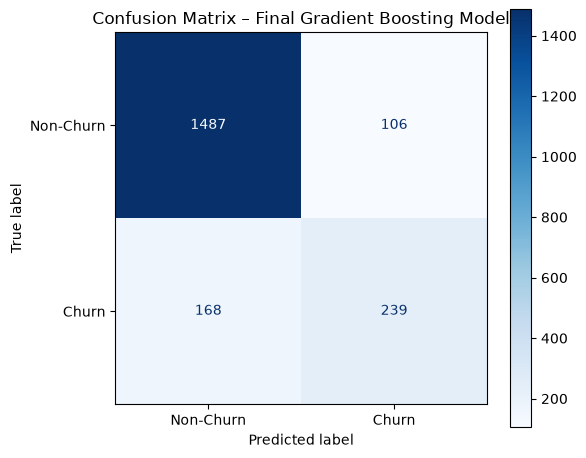

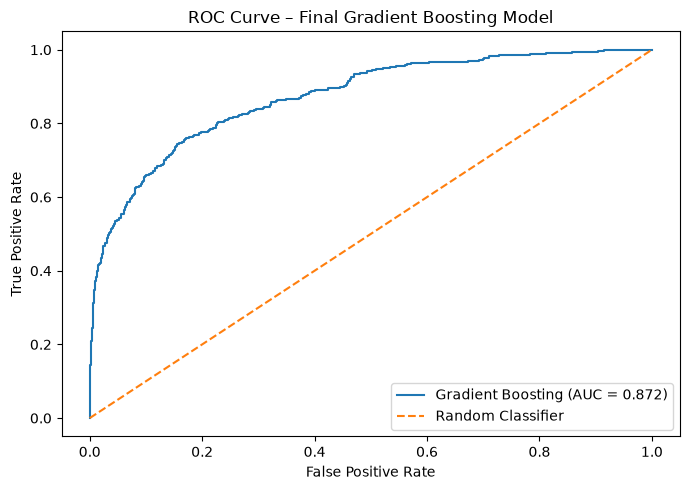

In [43]:
# Visual evaluation of the final churn model

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_curve,
    auc
)

# -------------------------------
# Confusion Matrix
# -------------------------------

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Non-Churn", "Churn"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title("Confusion Matrix – Final Gradient Boosting Model")

plt.tight_layout()
plt.show()


# -------------------------------
# ROC Curve
# -------------------------------

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    fpr,
    tpr,
    label=f"Gradient Boosting (AUC = {roc_auc:.3f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve – Final Gradient Boosting Model")
ax.legend()

plt.tight_layout()
plt.show()

#### Probability Calibration

Brier Score: 0.1035


,Mean Predicted Probability,Observed Churn Rate
0,0.0220,0.015
1,0.0433,0.015
2,0.0681,0.040
3,0.0978,0.035
4,0.1388,0.120
5,0.1889,0.115
6,0.2618,0.140
7,0.3700,0.275
8,0.5703,0.430
9,0.8449,0.850


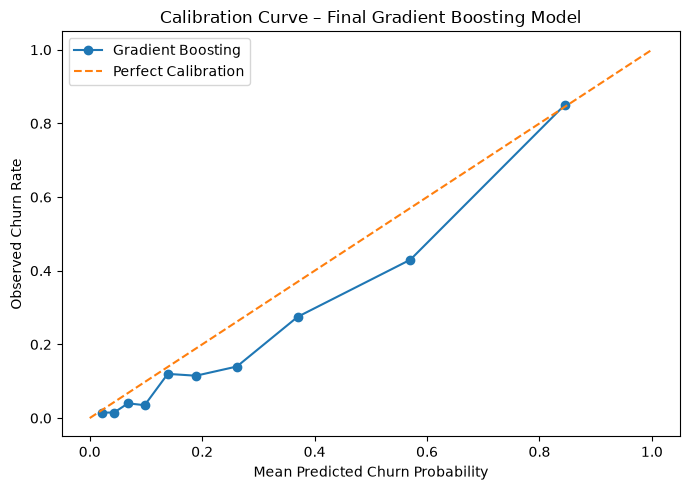

In [44]:
# Probability calibration assessment

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# Calculate Brier score
brier_score = brier_score_loss(y_test, y_prob)

print(f"Brier Score: {brier_score:.4f}")

# Calculate calibration curve
prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob,
    n_bins=10,
    strategy="quantile"
)

# Display calibration results
calibration_results = pd.DataFrame({
    "Mean Predicted Probability": prob_pred,
    "Observed Churn Rate": prob_true
}).round(4)

display(calibration_results)

# Plot calibration curve
plt.figure(figsize=(7, 5))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Gradient Boosting"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Churn Probability")
plt.ylabel("Observed Churn Rate")
plt.title("Calibration Curve – Final Gradient Boosting Model")
plt.legend()

plt.tight_layout()
plt.show()

,Brier Score,ROC-AUC
Model,,
Uncalibrated,0.1035,0.8718
Sigmoid,0.0984,0.8736
Isotonic,0.0980,0.8731


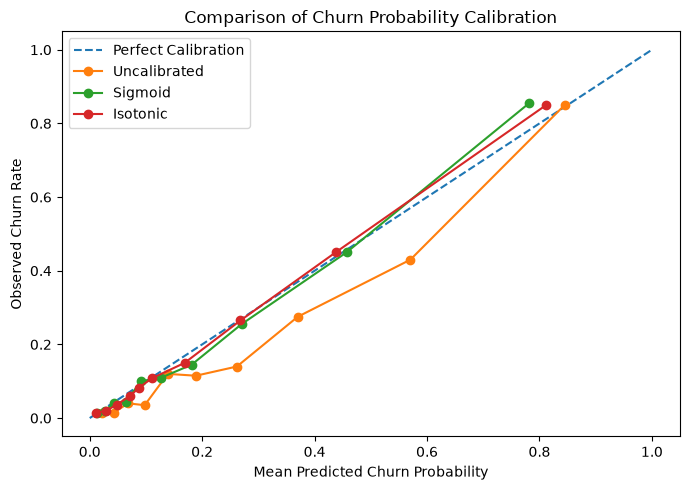

In [45]:
# Compare probability calibration methods

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score

# --------------------------------------------------
# Sigmoid calibration
# --------------------------------------------------

sigmoid_model = CalibratedClassifierCV(
    estimator=final_model,
    method="sigmoid",
    cv=5
)

sigmoid_model.fit(X_train, y_train)

sigmoid_prob = sigmoid_model.predict_proba(X_test)[:, 1]


# --------------------------------------------------
# Isotonic calibration
# --------------------------------------------------

isotonic_model = CalibratedClassifierCV(
    estimator=final_model,
    method="isotonic",
    cv=5
)

isotonic_model.fit(X_train, y_train)

isotonic_prob = isotonic_model.predict_proba(X_test)[:, 1]


# --------------------------------------------------
# Compare probability performance
# --------------------------------------------------

calibration_comparison = pd.DataFrame({
    "Model": [
        "Uncalibrated",
        "Sigmoid",
        "Isotonic"
    ],
    "Brier Score": [
        brier_score_loss(y_test, y_prob),
        brier_score_loss(y_test, sigmoid_prob),
        brier_score_loss(y_test, isotonic_prob)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, sigmoid_prob),
        roc_auc_score(y_test, isotonic_prob)
    ]
})

calibration_comparison = (
    calibration_comparison
    .set_index("Model")
    .round(4)
)

display(calibration_comparison)


# --------------------------------------------------
# Plot calibration curves
# --------------------------------------------------

plt.figure(figsize=(7, 5))

# Perfect calibration reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

# Uncalibrated model
true_uncal, pred_uncal = calibration_curve(
    y_test,
    y_prob,
    n_bins=10,
    strategy="quantile"
)

plt.plot(
    pred_uncal,
    true_uncal,
    marker="o",
    label="Uncalibrated"
)

# Sigmoid calibrated model
true_sigmoid, pred_sigmoid = calibration_curve(
    y_test,
    sigmoid_prob,
    n_bins=10,
    strategy="quantile"
)

plt.plot(
    pred_sigmoid,
    true_sigmoid,
    marker="o",
    label="Sigmoid"
)

# Isotonic calibrated model
true_isotonic, pred_isotonic = calibration_curve(
    y_test,
    isotonic_prob,
    n_bins=10,
    strategy="quantile"
)

plt.plot(
    pred_isotonic,
    true_isotonic,
    marker="o",
    label="Isotonic"
)

plt.xlabel("Mean Predicted Churn Probability")
plt.ylabel("Observed Churn Rate")
plt.title("Comparison of Churn Probability Calibration")
plt.legend()

plt.tight_layout()
plt.show()

### Probability Calibration

As the proposed risk-adjusted Customer Value framework uses continuous churn probabilities rather than only binary classifications, the calibration of the predicted probabilities was also assessed. The uncalibrated Gradient Boosting model achieved a Brier score of 0.1035. Examination of the calibration curve indicated that the model tended to overestimate churn risk across parts of the probability range.

Sigmoid and isotonic calibration were therefore compared. Both approaches improved probability calibration while maintaining the model's discriminatory performance. Sigmoid calibration reduced the Brier score to 0.0984 with a ROC-AUC of 0.8736, while isotonic calibration achieved the lowest Brier score of 0.0980 with a ROC-AUC of 0.8731.

Isotonic calibration was therefore selected for the final framework because it produced the lowest probability prediction error while maintaining strong discriminatory performance. The calibrated churn probabilities will consequently be used when adjusting baseline Customer Value.

In [46]:
# Store final calibrated churn probabilities for test customers

final_churn_probability = isotonic_prob

# Create results dataframe for the held-out test customers
churn_results = X_test.copy()

churn_results["actual_churn"] = y_test.values
churn_results["predicted_churn_probability"] = final_churn_probability
churn_results["predicted_retention_probability"] = (
    1 - churn_results["predicted_churn_probability"]
)

# Preview results
churn_results[
    [
        "actual_churn",
        "predicted_churn_probability",
        "predicted_retention_probability"
    ]
].head(10).round(4)

,actual_churn,predicted_churn_probability,predicted_retention_probability
5702,0,0.0205,0.9795
3667,0,0.0874,0.9126
1617,0,0.0449,0.9551
5673,0,0.0310,0.9690
4272,0,0.0938,0.9062
8270,0,0.1807,0.8193
7079,0,0.0634,0.9366
5295,0,0.2180,0.7820
845,0,0.4451,0.5549
5311,0,0.0812,0.9188


#### Churn Prediction Component Completed

## Baseline Customer Value Construction

The baseline Customer Value (CV) component uses account balance and product ownership to represent the financial depth and breadth of each customer's relationship with the bank. As the dataset does not contain longitudinal revenue or cost information, the resulting measure represents relative customer value rather than monetary Customer Lifetime Value.

Initial data inspection identified that 36.17% of customers have a zero account balance. A purely multiplicative relationship between balance and product ownership would therefore assign these customers a value of zero regardless of the number of products held. Consequently, multiplicative and additive formulations will be compared before selecting the final baseline CV specification.

In [47]:
# Baseline Customer Value formulation comparison

from sklearn.preprocessing import MinMaxScaler

# Create a separate dataframe for CV construction
cv_data = df[
    ["customer_id", "balance", "products_number"]
].copy()

# --------------------------------------------------
# Normalise balance
# --------------------------------------------------

balance_scaler = MinMaxScaler()

cv_data["balance_normalised"] = balance_scaler.fit_transform(
    cv_data[["balance"]]
)

# --------------------------------------------------
# Normalise product ownership
# --------------------------------------------------

product_scaler = MinMaxScaler()

cv_data["products_normalised"] = product_scaler.fit_transform(
    cv_data[["products_number"]]
)

# --------------------------------------------------
# 1. Multiplicative formulation
# --------------------------------------------------

cv_data["cv_multiplicative_raw"] = (
    cv_data["balance_normalised"]
    * cv_data["products_number"]
)

# Rescale multiplicative score to 0-100
multiplicative_scaler = MinMaxScaler(
    feature_range=(0, 100)
)

cv_data["cv_multiplicative"] = (
    multiplicative_scaler.fit_transform(
        cv_data[["cv_multiplicative_raw"]]
    )
)

# --------------------------------------------------
# 2. Equal-weight additive formulation
# --------------------------------------------------

cv_data["cv_additive"] = (
    0.5 * cv_data["balance_normalised"]
    + 0.5 * cv_data["products_normalised"]
) * 100

# --------------------------------------------------
# Compare overall distributions
# --------------------------------------------------

cv_comparison_summary = cv_data[
    [
        "cv_multiplicative",
        "cv_additive"
    ]
].describe().round(2)

display(cv_comparison_summary)

# --------------------------------------------------
# Examine zero-balance customers
# --------------------------------------------------

zero_balance_cv = cv_data[
    cv_data["balance"] == 0
]

zero_balance_summary = pd.DataFrame({
    "Measure": [
        "Number of zero-balance customers",
        "Zero CV under multiplicative method",
        "Zero CV under additive method",
        "Mean multiplicative CV",
        "Mean additive CV"
    ],
    "Value": [
        len(zero_balance_cv),
        (zero_balance_cv["cv_multiplicative"] == 0).sum(),
        (zero_balance_cv["cv_additive"] == 0).sum(),
        zero_balance_cv["cv_multiplicative"].mean(),
        zero_balance_cv["cv_additive"].mean()
    ]
})

display(zero_balance_summary.round(2))

# --------------------------------------------------
# Compare CV by number of products
# --------------------------------------------------

cv_by_products = (
    cv_data
    .groupby("products_number")
    .agg(
        customers=("customer_id", "count"),
        mean_balance=("balance", "mean"),
        mean_multiplicative_cv=("cv_multiplicative", "mean"),
        mean_additive_cv=("cv_additive", "mean")
    )
    .round(2)
)

display(cv_by_products)

# --------------------------------------------------
# Preview customer-level scores
# --------------------------------------------------

display(
    cv_data[
        [
            "customer_id",
            "balance",
            "products_number",
            "balance_normalised",
            "products_normalised",
            "cv_multiplicative",
            "cv_additive"
        ]
    ].head(10).round(4)
)

,cv_multiplicative,cv_additive
count,10000.00,10000.00
mean,13.57,24.08
std,13.28,13.24
min,0.00,0.00
25%,0.00,16.67
50%,13.63,21.75
75%,19.85,32.05
max,100.00,88.91


,Measure,Value
0,Number of zero-balance customers,3617.00
1,Zero CV under multiplicative method,3617.00
2,Zero CV under additive method,905.00
3,Mean multiplicative CV,0.00
4,Mean additive CV,13.08


,customers,mean_balance,mean_multiplicative_cv,mean_additive_cv
products_number,,,,
1,5084,98551.87,12.62,19.64
2,4590,51879.15,13.29,27.01
3,266,75458.33,28.99,48.37
4,60,93733.14,48.01,68.68


,customer_id,balance,products_number,balance_normalised,products_normalised,cv_multiplicative,cv_additive
0,15634602,0.00,1,0.0000,0.0000,0.0000,0.0000
1,15647311,83807.86,1,0.3340,0.0000,10.7315,16.7016
2,15619304,159660.80,3,0.6364,0.6667,61.3331,65.1512
3,15701354,0.00,2,0.0000,0.3333,0.0000,16.6667
4,15737888,125510.82,1,0.5002,0.0000,16.0715,25.0123
5,15574012,113755.78,2,0.4534,0.3333,29.1325,39.3364
6,15592531,0.00,2,0.0000,0.3333,0.0000,16.6667
7,15656148,115046.74,4,0.4585,1.0000,58.9263,72.9270
8,15792365,142051.07,2,0.5662,0.3333,36.3789,44.9752
9,15592389,134603.88,1,0.5365,0.0000,17.2358,26.8244


### Sensitivity of the Baseline CV Formulation

The initial comparison indicates that the multiplicative formulation is unsuitable for the main baseline CV measure because all zero-balance customers receive a score of zero regardless of their product ownership. The additive formulation preserves information from both components and is therefore considered more appropriate.

However, an additive formulation requires a decision regarding the relative weighting assigned to account balance and product ownership. As the dataset does not provide customer-level revenue or profitability information from which empirical weights could be estimated, a sensitivity analysis is conducted to determine whether reasonable alternative weighting assumptions materially change customer rankings.

In [48]:
# Sensitivity analysis for additive Customer Value weights

from scipy.stats import spearmanr

# --------------------------------------------------
# Construct alternative weighting scenarios
# --------------------------------------------------

weight_scenarios = {
    "Balance 70% / Products 30%": (0.70, 0.30),
    "Balance 60% / Products 40%": (0.60, 0.40),
    "Balance 50% / Products 50%": (0.50, 0.50),
    "Balance 40% / Products 60%": (0.40, 0.60),
    "Balance 30% / Products 70%": (0.30, 0.70)
}

for name, (balance_weight, product_weight) in weight_scenarios.items():

    cv_data[name] = (
        balance_weight * cv_data["balance_normalised"]
        + product_weight * cv_data["products_normalised"]
    ) * 100


# --------------------------------------------------
# Compare score distributions
# --------------------------------------------------

sensitivity_summary = (
    cv_data[list(weight_scenarios.keys())]
    .describe()
    .loc[["mean", "std", "min", "25%", "50%", "75%", "max"]]
    .round(2)
)

display(sensitivity_summary)


# --------------------------------------------------
# Compare customer rankings using Spearman correlation
# --------------------------------------------------

baseline_scenario = "Balance 50% / Products 50%"

rank_correlations = []

for scenario in weight_scenarios:

    correlation, _ = spearmanr(
        cv_data[baseline_scenario],
        cv_data[scenario]
    )

    rank_correlations.append({
        "Weighting Scenario": scenario,
        "Spearman Rank Correlation with 50/50": correlation
    })

rank_correlation_table = pd.DataFrame(rank_correlations)

rank_correlation_table[
    "Spearman Rank Correlation with 50/50"
] = rank_correlation_table[
    "Spearman Rank Correlation with 50/50"
].round(4)

display(rank_correlation_table)


# --------------------------------------------------
# Examine changes in top-value customers
# --------------------------------------------------

top_n = int(len(cv_data) * 0.10)

baseline_top_customers = set(
    cv_data
    .nlargest(top_n, baseline_scenario)["customer_id"]
)

top_customer_comparison = []

for scenario in weight_scenarios:

    scenario_top_customers = set(
        cv_data
        .nlargest(top_n, scenario)["customer_id"]
    )

    overlap = len(
        baseline_top_customers.intersection(
            scenario_top_customers
        )
    )

    top_customer_comparison.append({
        "Weighting Scenario": scenario,
        "Customers Shared with 50/50 Top 10%": overlap,
        "Top 10% Overlap (%)": (overlap / top_n) * 100
    })

top_customer_comparison = pd.DataFrame(
    top_customer_comparison
)

top_customer_comparison[
    "Top 10% Overlap (%)"
] = top_customer_comparison[
    "Top 10% Overlap (%)"
].round(2)

display(top_customer_comparison)

,Balance 70% / Products 30%,Balance 60% / Products 40%,Balance 50% / Products 50%,Balance 40% / Products 60%,Balance 30% / Products 70%
mean,26.64,25.36,24.08,22.80,21.52
std,16.59,14.57,13.24,12.80,13.35
min,0.00,0.00,0.00,0.00,0.00
25%,10.00,13.33,16.67,17.71,13.28
50%,29.42,26.00,21.75,20.00,21.86
75%,39.49,35.55,32.05,27.13,23.33
max,90.00,86.69,88.91,91.13,93.34


,Weighting Scenario,Spearman Rank Correlation with 50/50
0,Balance 70% / Products 30%,0.9448
1,Balance 60% / Products 40%,0.9724
2,Balance 50% / Products 50%,1.0000
3,Balance 40% / Products 60%,0.8582
4,Balance 30% / Products 70%,0.6223


,Weighting Scenario,Customers Shared with 50/50 Top 10%,Top 10% Overlap (%)
0,Balance 70% / Products 30%,803,80.3
1,Balance 60% / Products 40%,939,93.9
2,Balance 50% / Products 50%,1000,100.0
3,Balance 40% / Products 60%,990,99.0
4,Balance 30% / Products 70%,901,90.1


### Baseline CV Weighting Selection

The sensitivity analysis indicates that customer rankings remain relatively stable under moderate changes to the weighting of balance and product ownership. Compared with the 50/50 specification, the 60/40 balance-product weighting produced a Spearman rank correlation of 0.9724 and retained 93.9% of the same customers within the top 10% of baseline CV. The 40/60 specification retained 99.0% of the same top-value customers.

Greater changes in the weighting produced larger differences in the overall rankings, particularly when product ownership was assigned 70% of the total weight. This demonstrates that the weighting assumption can influence the relative valuation of customers and should therefore be recognised as a limitation of the proxy-based CV measure.

A 50/50 weighting is retained for the baseline CV because the available dataset does not contain customer-level profitability information that would provide an empirical basis for assigning greater financial importance to either component. Equal weighting therefore provides a transparent and neutral specification while allowing both account balance and product ownership to contribute independently to customer value.

In [49]:
# --------------------------------------------------
# Final Baseline Customer Value
# --------------------------------------------------

# Equal weighting of normalised balance and product ownership
cv_data["baseline_cv"] = (
    0.50 * cv_data["balance_normalised"]
    + 0.50 * cv_data["products_normalised"]
) * 100

# Summary statistics
baseline_cv_summary = (
    cv_data["baseline_cv"]
    .describe()
    .round(2)
)

print("Final Baseline Customer Value Summary")
display(baseline_cv_summary)

# Show example customers
display(
    cv_data[
        [
            "customer_id",
            "balance",
            "products_number",
            "balance_normalised",
            "products_normalised",
            "baseline_cv"
        ]
    ].head(10).round(4)
)

# Basic validation
print("Missing baseline CV values:", cv_data["baseline_cv"].isna().sum())
print("Minimum baseline CV:", round(cv_data["baseline_cv"].min(), 2))
print("Maximum baseline CV:", round(cv_data["baseline_cv"].max(), 2))

Final Baseline Customer Value Summary


count    10000.00
mean        24.08
std         13.24
min          0.00
25%         16.67
50%         21.75
75%         32.05
max         88.91
Name: baseline_cv, dtype: float64

,customer_id,balance,products_number,balance_normalised,products_normalised,baseline_cv
0,15634602,0.00,1,0.0000,0.0000,0.0000
1,15647311,83807.86,1,0.3340,0.0000,16.7016
2,15619304,159660.80,3,0.6364,0.6667,65.1512
3,15701354,0.00,2,0.0000,0.3333,16.6667
4,15737888,125510.82,1,0.5002,0.0000,25.0123
5,15574012,113755.78,2,0.4534,0.3333,39.3364
6,15592531,0.00,2,0.0000,0.3333,16.6667
7,15656148,115046.74,4,0.4585,1.0000,72.9270
8,15792365,142051.07,2,0.5662,0.3333,44.9752
9,15592389,134603.88,1,0.5365,0.0000,26.8244


Missing baseline CV values: 0
Minimum baseline CV: 0.0
Maximum baseline CV: 88.91


### Baseline Customer Value Segmentation

To support comparison between baseline and churn risk-adjusted Customer Value, customers are divided into four relative value segments based on the quartiles of the baseline CV distribution. This provides a consistent basis for examining whether incorporating churn risk changes the value classification and prioritisation of individual customers.

In [50]:
# --------------------------------------------------
# Baseline Customer Value Segmentation
# --------------------------------------------------

# Divide customers into four relative value groups
cv_data["baseline_value_segment"] = pd.qcut(
    cv_data["baseline_cv"],
    q=4,
    labels=["Low", "Lower-Medium", "Upper-Medium", "High"],
    duplicates="drop"
)

# Segment summary
baseline_segment_summary = (
    cv_data
    .groupby(
        "baseline_value_segment",
        observed=True
    )
    .agg(
        customers=("customer_id", "count"),
        min_cv=("baseline_cv", "min"),
        mean_cv=("baseline_cv", "mean"),
        median_cv=("baseline_cv", "median"),
        max_cv=("baseline_cv", "max")
    )
    .round(2)
)

print("Baseline Customer Value Segments")
display(baseline_segment_summary)

# Check distribution
segment_distribution = (
    cv_data["baseline_value_segment"]
    .value_counts(sort=False)
)

print("\nCustomers per segment:")
display(segment_distribution)

Baseline Customer Value Segments


,customers,min_cv,mean_cv,median_cv,max_cv
baseline_value_segment,,,,,
Low,3973,0.00,12.52,16.67,16.67
Lower-Medium,1027,16.68,19.61,19.75,21.75
Upper-Medium,2500,21.76,26.37,26.16,32.05
High,2500,32.05,41.99,40.49,88.91



Customers per segment:


baseline_value_segment
Low             3973
Lower-Medium    1027
Upper-Medium    2500
High            2500
Name: count, dtype: int64

### Baseline Value Segment Observation

The baseline CV segments are not equally sized because a substantial number of customers share identical CV scores. In particular, customers with zero account balances and identical levels of product ownership receive the same baseline value score. These tied observations were retained within the same value segment rather than being artificially separated to create equally sized groups.

## Churn Risk-Adjusted Customer Value Integration

The final framework integrates the baseline Customer Value score with the calibrated probability of customer churn. The isotonic-calibrated churn probability is converted into an estimated retention probability and multiplied by the baseline CV score.

The primary evaluation is performed on the held-out test set so that the churn probabilities used in the risk-adjustment calculation are generated for customers who were not used during model development.

In [51]:
# --------------------------------------------------
# Integrate baseline CV with calibrated churn risk
# --------------------------------------------------

# Create test customer identifiers using the original dataset index
test_customer_ids = df.loc[X_test.index, "customer_id"]

# Create test-set framework dataframe
framework_results = pd.DataFrame({
    "customer_id": test_customer_ids.values,
    "actual_churn": y_test.values,
    "predicted_churn_probability": isotonic_prob
})

# Convert churn probability to retention probability
framework_results["predicted_retention_probability"] = (
    1 - framework_results["predicted_churn_probability"]
)

# --------------------------------------------------
# Merge baseline CV information
# --------------------------------------------------

framework_results = framework_results.merge(
    cv_data[
        [
            "customer_id",
            "balance",
            "products_number",
            "baseline_cv",
            "baseline_value_segment"
        ]
    ],
    on="customer_id",
    how="left"
)

# --------------------------------------------------
# Calculate churn risk-adjusted Customer Value
# --------------------------------------------------

framework_results["risk_adjusted_cv"] = (
    framework_results["baseline_cv"]
    * framework_results["predicted_retention_probability"]
)

# --------------------------------------------------
# Basic validation
# --------------------------------------------------

print("Test customers:", len(framework_results))
print(
    "Missing baseline CV values:",
    framework_results["baseline_cv"].isna().sum()
)
print(
    "Missing risk-adjusted CV values:",
    framework_results["risk_adjusted_cv"].isna().sum()
)

# --------------------------------------------------
# Summary statistics
# --------------------------------------------------

cv_integration_summary = framework_results[
    [
        "baseline_cv",
        "predicted_churn_probability",
        "predicted_retention_probability",
        "risk_adjusted_cv"
    ]
].describe().round(2)

display(cv_integration_summary)

# --------------------------------------------------
# Preview customer-level results
# --------------------------------------------------

display(
    framework_results[
        [
            "customer_id",
            "baseline_cv",
            "predicted_churn_probability",
            "predicted_retention_probability",
            "risk_adjusted_cv",
            "actual_churn"
        ]
    ]
    .head(10)
    .round(4)
)

Test customers: 2000
Missing baseline CV values: 0
Missing risk-adjusted CV values: 0


,baseline_cv,predicted_churn_probability,predicted_retention_probability,risk_adjusted_cv
count,2000.00,2000.00,2000.00,2000.00
mean,24.21,0.20,0.80,18.78
std,13.42,0.24,0.24,11.38
min,0.00,0.00,0.01,0.00
25%,16.67,0.05,0.73,13.94
50%,21.67,0.09,0.91,16.41
75%,32.78,0.27,0.95,25.04
max,83.33,0.99,1.00,57.17


,customer_id,baseline_cv,predicted_churn_probability,predicted_retention_probability,risk_adjusted_cv,actual_churn
0,15749540,16.6667,0.0205,0.9795,16.3250,0
1,15807340,42.7776,0.0874,0.9126,39.0384,0
2,15801062,16.6667,0.0449,0.9551,15.9185,0
3,15572801,44.4455,0.0310,0.9690,43.0684,0
4,15600708,15.5096,0.0938,0.9062,14.0541,0
5,15703544,0.0000,0.1807,0.8193,0.0000,0
6,15704081,42.7095,0.0634,0.9366,40.0014,0
7,15801788,36.9760,0.2180,0.7820,28.9169,0
8,15592222,15.9430,0.4451,0.5549,8.8468,0
9,15584338,16.6667,0.0812,0.9188,15.3134,0


### Initial Risk-Adjustment Results

The churn risk-adjustment was successfully applied to all 2,000 customers in the held-out test set, with no missing baseline or risk-adjusted CV scores. The mean Customer Value decreased from 24.21 under the baseline measure to 18.78 after incorporating predicted retention probability.

The reduction in value is expected because the risk-adjusted framework discounts baseline CV according to each customer's predicted probability of churn. The subsequent analysis therefore focuses on whether differences in predicted churn risk materially alter the relative ranking and prioritisation of customers rather than simply examining the reduction in absolute scores.

In [52]:
# --------------------------------------------------
# Customer Ranking Analysis
# --------------------------------------------------

# Rank customers from highest to lowest value
framework_results["baseline_rank"] = (
    framework_results["baseline_cv"]
    .rank(method="min", ascending=False)
)

framework_results["risk_adjusted_rank"] = (
    framework_results["risk_adjusted_cv"]
    .rank(method="min", ascending=False)
)

# Positive = customer moves down after churn adjustment
# Negative = customer moves up
framework_results["rank_change"] = (
    framework_results["risk_adjusted_rank"]
    - framework_results["baseline_rank"]
)

framework_results["absolute_rank_change"] = (
    framework_results["rank_change"].abs()
)

# --------------------------------------------------
# Overall rank relationship
# --------------------------------------------------

spearman_rank_corr = framework_results[
    ["baseline_cv", "risk_adjusted_cv"]
].corr(method="spearman").iloc[0, 1]

print(
    "Spearman rank correlation:",
    round(spearman_rank_corr, 4)
)

print(
    "Mean absolute rank change:",
    round(framework_results["absolute_rank_change"].mean(), 2)
)

print(
    "Median absolute rank change:",
    round(framework_results["absolute_rank_change"].median(), 2)
)

print(
    "Maximum absolute rank change:",
    round(framework_results["absolute_rank_change"].max(), 2)
)

# --------------------------------------------------
# Top 10% comparison
# --------------------------------------------------

top_n = int(len(framework_results) * 0.10)

baseline_top_10 = set(
    framework_results
    .nlargest(top_n, "baseline_cv")["customer_id"]
)

risk_adjusted_top_10 = set(
    framework_results
    .nlargest(top_n, "risk_adjusted_cv")["customer_id"]
)

shared_top_10 = baseline_top_10.intersection(
    risk_adjusted_top_10
)

top_10_overlap = (
    len(shared_top_10) / top_n * 100
)

print("\nTop 10% customers:", top_n)
print(
    "Customers remaining in top 10%:",
    len(shared_top_10)
)
print(
    "Top 10% overlap:",
    round(top_10_overlap, 2),
    "%"
)

# --------------------------------------------------
# Customers with largest downward movements
# --------------------------------------------------

largest_downward_moves = (
    framework_results
    .sort_values("rank_change", ascending=False)
    [
        [
            "customer_id",
            "baseline_cv",
            "predicted_churn_probability",
            "risk_adjusted_cv",
            "baseline_rank",
            "risk_adjusted_rank",
            "rank_change",
            "actual_churn"
        ]
    ]
    .head(10)
    .round(4)
)

print("\nLargest downward ranking movements:")
display(largest_downward_moves)

# --------------------------------------------------
# Customers with largest upward movements
# --------------------------------------------------

largest_upward_moves = (
    framework_results
    .sort_values("rank_change", ascending=True)
    [
        [
            "customer_id",
            "baseline_cv",
            "predicted_churn_probability",
            "risk_adjusted_cv",
            "baseline_rank",
            "risk_adjusted_rank",
            "rank_change",
            "actual_churn"
        ]
    ]
    .head(10)
    .round(4)
)

print("\nLargest upward ranking movements:")
display(largest_upward_moves)

Spearman rank correlation: 0.7023
Mean absolute rank change: 250.6
Median absolute rank change: 155.0
Maximum absolute rank change: 1803.0

Top 10% customers: 200
Customers remaining in top 10%: 127
Top 10% overlap: 63.5 %

Largest downward ranking movements:


,customer_id,baseline_cv,predicted_churn_probability,risk_adjusted_cv,baseline_rank,risk_adjusted_rank,rank_change,actual_churn
501,15703793,76.6533,0.9857,1.0950,3.0,1806.0,1803.0,1
248,15696989,61.1321,0.9857,0.8733,21.0,1811.0,1790.0,1
1853,15647898,59.3508,0.9857,0.8479,25.0,1812.0,1787.0,1
860,15634551,72.9671,0.9714,2.0848,8.0,1787.0,1779.0,1
338,15806808,55.7093,0.9857,0.7958,35.0,1814.0,1779.0,1
74,15719508,74.1543,0.9714,2.1187,6.0,1785.0,1779.0,1
723,15624180,76.7383,0.9692,2.3608,2.0,1781.0,1779.0,1
586,15589017,55.5262,0.9857,0.7932,37.0,1815.0,1778.0,1
927,15655082,55.6673,0.9857,0.7963,36.0,1813.0,1777.0,1
1521,15779176,55.0330,0.9774,1.2449,38.0,1803.0,1765.0,1



Largest upward ranking movements:


,customer_id,baseline_cv,predicted_churn_probability,risk_adjusted_cv,baseline_rank,risk_adjusted_rank,rank_change,actual_churn
1299,15581479,16.5767,0.0400,15.9129,1732.0,1257.0,-475.0,0
1532,15571281,15.8556,0.0276,15.4181,1745.0,1362.0,-383.0,0
191,15609545,16.6289,0.0713,15.4428,1729.0,1359.0,-370.0,0
840,15612139,16.5478,0.0723,15.3513,1733.0,1374.0,-359.0,1
1846,15738411,20.8249,0.0276,20.2503,1045.0,692.0,-353.0,0
1417,15579892,22.4426,0.0139,22.1301,957.0,604.0,-353.0,0
1971,15747014,20.9737,0.0268,20.4126,1035.0,682.0,-353.0,0
1046,15576162,18.3740,0.0149,18.1001,1147.0,801.0,-346.0,0
1891,15789714,20.5264,0.0449,19.6051,1066.0,724.0,-342.0,0
829,15665110,15.8518,0.0429,15.1723,1747.0,1406.0,-341.0,0


### Effect of Churn Risk on Customer Rankings

The incorporation of predicted churn risk materially changed the relative prioritisation of customers. Baseline and risk-adjusted CV produced a Spearman rank correlation of 0.7023, indicating that although the two measures remain positively associated, the inclusion of churn risk results in substantial changes to customer ordering.

The mean absolute change was approximately 251 ranking positions, with a median change of 155 positions. The largest observed movement was 1,803 positions. Changes were also evident among the customers initially considered most valuable. Of the 200 customers representing the top 10% by baseline CV, only 127 remained within the top 10% following risk adjustment, representing an overlap of 63.5%.

The largest downward movements were concentrated among customers with high baseline CV but very high predicted churn probabilities. This demonstrates that the framework can identify customers whose financial value appears high when considered independently, but whose relative value is substantially reduced when their estimated likelihood of remaining with the bank is incorporated.

In [53]:
# --------------------------------------------------
# Value Segment Movement Analysis
# --------------------------------------------------

# Baseline segment boundaries obtained from the
# baseline CV distribution
q1 = cv_data["baseline_cv"].quantile(0.25)
q2 = cv_data["baseline_cv"].quantile(0.50)
q3 = cv_data["baseline_cv"].quantile(0.75)

print("Baseline CV thresholds:")
print("25th percentile:", round(q1, 2))
print("50th percentile:", round(q2, 2))
print("75th percentile:", round(q3, 2))


# --------------------------------------------------
# Apply baseline thresholds to risk-adjusted CV
# --------------------------------------------------

def assign_value_segment(value):
    if value <= q1:
        return "Low"
    elif value <= q2:
        return "Lower-Medium"
    elif value <= q3:
        return "Upper-Medium"
    else:
        return "High"


framework_results["risk_adjusted_value_segment"] = (
    framework_results["risk_adjusted_cv"]
    .apply(assign_value_segment)
)


# Ensure ordered categories
segment_order = [
    "Low",
    "Lower-Medium",
    "Upper-Medium",
    "High"
]

framework_results["risk_adjusted_value_segment"] = pd.Categorical(
    framework_results["risk_adjusted_value_segment"],
    categories=segment_order,
    ordered=True
)


# --------------------------------------------------
# Segment transition matrix
# --------------------------------------------------

segment_transition = pd.crosstab(
    framework_results["baseline_value_segment"],
    framework_results["risk_adjusted_value_segment"],
    margins=True
)

print("\nBaseline to Risk-Adjusted Segment Transition:")
display(segment_transition)


# --------------------------------------------------
# Percentage transition matrix
# --------------------------------------------------

segment_transition_pct = pd.crosstab(
    framework_results["baseline_value_segment"],
    framework_results["risk_adjusted_value_segment"],
    normalize="index"
) * 100

segment_transition_pct = segment_transition_pct.round(2)

print("\nTransition Percentages:")
display(segment_transition_pct)


# --------------------------------------------------
# Determine direction of segment movement
# --------------------------------------------------

segment_numeric = {
    "Low": 1,
    "Lower-Medium": 2,
    "Upper-Medium": 3,
    "High": 4
}

framework_results["baseline_segment_numeric"] = (
    framework_results["baseline_value_segment"]
    .astype(str)
    .map(segment_numeric)
)

framework_results["risk_adjusted_segment_numeric"] = (
    framework_results["risk_adjusted_value_segment"]
    .astype(str)
    .map(segment_numeric)
)

framework_results["segment_change"] = (
    framework_results["risk_adjusted_segment_numeric"]
    - framework_results["baseline_segment_numeric"]
)


# --------------------------------------------------
# Summarise movements
# --------------------------------------------------

movement_summary = pd.Series({
    "Moved Down": (framework_results["segment_change"] < 0).sum(),
    "No Change": (framework_results["segment_change"] == 0).sum(),
    "Moved Up": (framework_results["segment_change"] > 0).sum()
})

movement_summary_pct = (
    movement_summary / len(framework_results) * 100
).round(2)

movement_results = pd.DataFrame({
    "Customers": movement_summary,
    "Percentage": movement_summary_pct
})

print("\nOverall Segment Movement:")
display(movement_results)


# --------------------------------------------------
# Focus specifically on baseline High-value customers
# --------------------------------------------------

high_value_customers = framework_results[
    framework_results["baseline_value_segment"] == "High"
]

high_value_summary = (
    high_value_customers[
        "risk_adjusted_value_segment"
    ]
    .value_counts(sort=False)
    .reindex(segment_order, fill_value=0)
)

high_value_summary = pd.DataFrame({
    "Customers": high_value_summary,
    "Percentage": (
        high_value_summary /
        len(high_value_customers) * 100
    ).round(2)
})

print("\nWhere Baseline High-Value Customers Move:")
display(high_value_summary)

Baseline CV thresholds:
25th percentile: 16.67
50th percentile: 21.75
75th percentile: 32.05

Baseline to Risk-Adjusted Segment Transition:


risk_adjusted_value_segment,Low,Lower-Medium,Upper-Medium,High,All
baseline_value_segment,,,,,
Low,798,0,0,0,798
Lower-Medium,118,87,0,0,205
Upper-Medium,135,138,206,0,479
High,87,17,111,303,518
All,1138,242,317,303,2000



Transition Percentages:


risk_adjusted_value_segment,Low,Lower-Medium,Upper-Medium,High
baseline_value_segment,,,,
Low,100.00,0.00,0.00,0.00
Lower-Medium,57.56,42.44,0.00,0.00
Upper-Medium,28.18,28.81,43.01,0.00
High,16.80,3.28,21.43,58.49



Overall Segment Movement:


,Customers,Percentage
Moved Down,606,30.3
No Change,1394,69.7
Moved Up,0,0.0



Where Baseline High-Value Customers Move:


,Customers,Percentage
risk_adjusted_value_segment,,
Low,87,16.80
Lower-Medium,17,3.28
Upper-Medium,111,21.43
High,303,58.49


### Customer Value Segment Changes

The effect of churn adjustment was also examined using the value-segment thresholds established from the baseline CV distribution. The same thresholds were applied to the risk-adjusted scores, allowing changes in customer classification to be attributed directly to the incorporation of predicted churn risk.

Overall, 606 of the 2,000 test customers (30.3%) moved into a lower value segment, while 1,394 (69.7%) remained within their original segment. No customers moved into a higher absolute value segment because the risk-adjustment calculation can only maintain or reduce the baseline CV score.

The effect was particularly notable among customers initially classified as High value. Of the 518 baseline High-value customers, only 303 (58.49%) remained in the High segment after adjustment. A further 111 (21.43%) moved to Upper-Medium, 17 (3.28%) moved to Lower-Medium and 87 (16.80%) moved to Low. Therefore, 41.51% of customers initially classified as High value were reclassified once predicted churn risk was incorporated.

These results demonstrate that the risk-adjustment process provides additional differentiation beyond the baseline financial-value measure. In particular, customers who appear highly valuable based on balance and product ownership alone may receive substantially lower valuations when their predicted likelihood of remaining with the bank is considered.

In [54]:
# --------------------------------------------------
# High-Value / High-Risk Customer Analysis
# --------------------------------------------------

# High value = customers in the baseline High segment
# High risk = predicted churn probability >= 0.50

framework_results["high_value"] = (
    framework_results["baseline_value_segment"] == "High"
)

framework_results["high_churn_risk"] = (
    framework_results["predicted_churn_probability"] >= 0.50
)

framework_results["high_value_high_risk"] = (
    framework_results["high_value"]
    & framework_results["high_churn_risk"]
)


# --------------------------------------------------
# Overall high-value / high-risk group
# --------------------------------------------------

hvhr = framework_results[
    framework_results["high_value_high_risk"]
].copy()

print("High-value customers:", 
      framework_results["high_value"].sum())

print("High-value / high-risk customers:", len(hvhr))

print(
    "Percentage of high-value customers classified as high risk:",
    round(
        len(hvhr) /
        framework_results["high_value"].sum() * 100,
        2
    ),
    "%"
)


# --------------------------------------------------
# Actual churn within this group
# --------------------------------------------------

print(
    "\nActual churners among high-value / high-risk customers:",
    hvhr["actual_churn"].sum()
)

print(
    "Actual churn rate:",
    round(hvhr["actual_churn"].mean() * 100, 2),
    "%"
)


# --------------------------------------------------
# Compare their baseline and risk-adjusted CV
# --------------------------------------------------

hvhr_summary = hvhr[
    [
        "baseline_cv",
        "predicted_churn_probability",
        "risk_adjusted_cv"
    ]
].agg(["mean", "median", "min", "max"]).round(2)

print("\nHigh-Value / High-Risk Customer Summary:")
display(hvhr_summary)


# --------------------------------------------------
# Average reduction in CV
# --------------------------------------------------

hvhr["cv_reduction"] = (
    hvhr["baseline_cv"] -
    hvhr["risk_adjusted_cv"]
)

hvhr["cv_reduction_pct"] = (
    hvhr["cv_reduction"] /
    hvhr["baseline_cv"] * 100
)

print(
    "\nMean CV reduction:",
    round(hvhr["cv_reduction"].mean(), 2)
)

print(
    "Mean percentage CV reduction:",
    round(hvhr["cv_reduction_pct"].mean(), 2),
    "%"
)


# --------------------------------------------------
# Show highest baseline-value customers at high risk
# --------------------------------------------------

high_value_high_risk_table = (
    hvhr[
        [
            "customer_id",
            "baseline_cv",
            "predicted_churn_probability",
            "risk_adjusted_cv",
            "baseline_rank",
            "risk_adjusted_rank",
            "actual_churn"
        ]
    ]
    .sort_values("baseline_cv", ascending=False)
    .head(15)
)

print("\nHighest-Value Customers with High Predicted Churn Risk:")
display(high_value_high_risk_table)

High-value customers: 518
High-value / high-risk customers: 92
Percentage of high-value customers classified as high risk: 17.76 %

Actual churners among high-value / high-risk customers: 80
Actual churn rate: 86.96 %

High-Value / High-Risk Customer Summary:


,baseline_cv,predicted_churn_probability,risk_adjusted_cv
mean,49.30,0.82,7.87
median,48.65,0.88,5.99
min,32.21,0.50,0.65
max,83.33,0.99,26.33



Mean CV reduction: 41.43
Mean percentage CV reduction: 81.68 %

Highest-Value Customers with High Predicted Churn Risk:


,customer_id,baseline_cv,predicted_churn_probability,risk_adjusted_cv,baseline_rank,risk_adjusted_rank,actual_churn
654,15757408,83.333333,0.933159,5.570085,1.0,1724.0,1
723,15624180,76.738306,0.969236,2.360780,2.0,1781.0,1
501,15703793,76.653340,0.985714,1.095048,3.0,1806.0,1
1788,15679770,76.222517,0.928521,5.448286,4.0,1726.0,1
1224,15625824,74.182304,0.907707,6.846476,5.0,1705.0,1
74,15719508,74.154259,0.971429,2.118693,6.0,1785.0,1
49,15668283,73.578751,0.956996,3.164156,7.0,1765.0,1
860,15634551,72.967116,0.971429,2.084775,8.0,1787.0,1
309,15622033,70.236007,0.905041,6.669509,9.0,1711.0,1
1974,15656822,67.459806,0.934352,4.428615,10.0,1747.0,1


### Identification of High-Value Customers at Elevated Churn Risk

To examine whether the framework could identify customers whose financial value may be overstated when churn risk is ignored, customers within the baseline High-value segment were assessed against their predicted churn probabilities. A probability threshold of 0.50 was used to identify customers for whom the model predicted churn to be more likely than retention.

Of the 518 customers initially classified as High value, 92 (17.76%) were identified as having a predicted churn probability of at least 50%. Within this group, 80 customers actually churned, representing an observed churn rate of 86.96%.

The financial impact of the adjustment was substantial. High-value/high-risk customers had a mean baseline CV of 49.30, which fell to a mean risk-adjusted CV of 7.87. This represented an average reduction of 81.68%. Individual customer rankings were also substantially affected. For example, the customer ranked first according to baseline CV had a predicted churn probability of 93.32%, causing the customer's CV to fall from 83.33 to 5.57 and their ranking to fall from first to 1,724th after risk adjustment.

These findings demonstrate the practical distinction between the baseline and risk-adjusted approaches. The baseline CV identifies customers with stronger financial relationships based on balance and product ownership, whereas the proposed framework additionally distinguishes customers whose apparent financial value is accompanied by a high predicted risk of attrition.

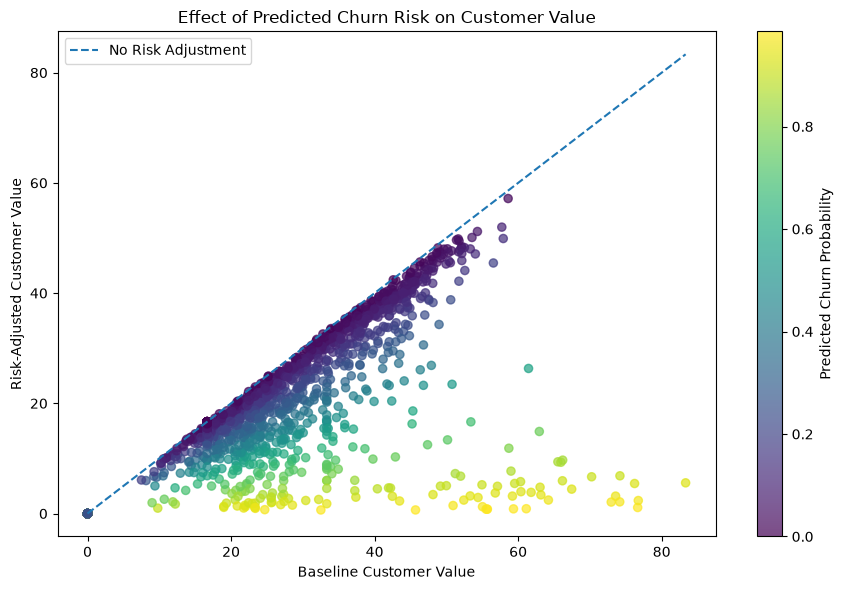

In [55]:
# --------------------------------------------------
# Visualise Baseline CV vs Risk-Adjusted CV
# --------------------------------------------------

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    framework_results["baseline_cv"],
    framework_results["risk_adjusted_cv"],
    c=framework_results["predicted_churn_probability"],
    cmap="viridis",
    alpha=0.7,
    s=35
)

# Reference line: no risk adjustment
max_cv = framework_results["baseline_cv"].max()

plt.plot(
    [0, max_cv],
    [0, max_cv],
    linestyle="--",
    linewidth=1.5,
    label="No Risk Adjustment"
)

plt.colorbar(
    scatter,
    label="Predicted Churn Probability"
)

plt.xlabel("Baseline Customer Value")
plt.ylabel("Risk-Adjusted Customer Value")
plt.title("Effect of Predicted Churn Risk on Customer Value")

plt.legend()
plt.tight_layout()

plt.savefig(
    "../outputs/figures/baseline_vs_risk_adjusted_cv.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Effect of Churn Risk on Customer Value

The figure above illustrates the relationship between baseline Customer Value and churn risk-adjusted Customer Value across the test set. The dashed diagonal represents the position customers would occupy if no churn adjustment were applied, while the colour scale represents each customer's predicted probability of churn.

Customers with low predicted churn probabilities remain relatively close to the diagonal because a greater proportion of their baseline value is retained. As predicted churn risk increases, customers move progressively further below the reference line, resulting in larger reductions in their risk-adjusted value. The effect is particularly visible among several customers with high baseline CV scores but very high predicted churn probabilities, whose adjusted values fall substantially despite their initially strong financial-value position.

The figure therefore demonstrates how the proposed framework differentiates between financial value and the value retained after accounting for predicted customer attrition risk.

In [56]:
# --------------------------------------------------
# Customer Value Reduction Analysis
# --------------------------------------------------

framework_results["cv_reduction"] = (
    framework_results["baseline_cv"]
    - framework_results["risk_adjusted_cv"]
)

framework_results["cv_reduction_pct"] = np.where(
    framework_results["baseline_cv"] > 0,
    (
        framework_results["cv_reduction"]
        / framework_results["baseline_cv"]
    ) * 100,
    0
)


# Overall reduction
print("Overall Customer Value Reduction")

print(
    "Mean baseline CV:",
    round(framework_results["baseline_cv"].mean(), 2)
)

print(
    "Mean risk-adjusted CV:",
    round(framework_results["risk_adjusted_cv"].mean(), 2)
)

print(
    "Mean absolute CV reduction:",
    round(framework_results["cv_reduction"].mean(), 2)
)

print(
    "Percentage reduction in mean CV:",
    round(
        (
            1 -
            framework_results["risk_adjusted_cv"].mean()
            / framework_results["baseline_cv"].mean()
        ) * 100,
        2
    ),
    "%"
)


# --------------------------------------------------
# Create churn-risk groups
# --------------------------------------------------

risk_bins = [0, 0.25, 0.50, 0.75, 1.0]

risk_labels = [
    "Low (<25%)",
    "Moderate (25-49%)",
    "High (50-74%)",
    "Very High (75%+)"
]

framework_results["churn_risk_group"] = pd.cut(
    framework_results["predicted_churn_probability"],
    bins=risk_bins,
    labels=risk_labels,
    include_lowest=True,
    right=False
)


# --------------------------------------------------
# CV reduction by churn-risk group
# --------------------------------------------------

risk_reduction_summary = (
    framework_results
    .groupby("churn_risk_group", observed=False)
    .agg(
        customers=("customer_id", "count"),
        mean_churn_probability=(
            "predicted_churn_probability", "mean"
        ),
        mean_baseline_cv=("baseline_cv", "mean"),
        mean_risk_adjusted_cv=("risk_adjusted_cv", "mean"),
        mean_cv_reduction=("cv_reduction", "mean"),
        actual_churn_rate=("actual_churn", "mean")
    )
)

risk_reduction_summary[
    "mean_churn_probability"
] *= 100

risk_reduction_summary[
    "actual_churn_rate"
] *= 100

risk_reduction_summary = risk_reduction_summary.round(2)

print("\nCustomer Value Reduction by Predicted Churn Risk:")
display(risk_reduction_summary)

Overall Customer Value Reduction
Mean baseline CV: 24.21
Mean risk-adjusted CV: 18.78
Mean absolute CV reduction: 5.42
Percentage reduction in mean CV: 22.41 %

Customer Value Reduction by Predicted Churn Risk:


,customers,mean_churn_probability,mean_baseline_cv,mean_risk_adjusted_cv,mean_cv_reduction,actual_churn_rate
churn_risk_group,,,,,,
Low (<25%),1476,8.29,23.90,21.86,2.04,7.86
Moderate (25-49%),281,35.93,21.17,13.57,7.60,33.10
High (50-74%),108,60.34,24.83,9.75,15.08,67.59
Very High (75%+),135,88.90,33.43,3.24,30.18,92.59


### Customer Value Reduction Across Churn-Risk Groups

Across the full test set, mean Customer Value decreased from 24.21 under the baseline measure to 18.78 following churn adjustment, representing a 22.41% reduction in mean CV. However, the effect of the adjustment differed substantially according to predicted churn risk.

Customers within the Low-risk group experienced a relatively small mean CV reduction of 2.04, whereas the reduction increased to 7.60 for Moderate-risk customers and 15.08 for High-risk customers. The largest effect occurred among the Very High-risk group, where mean baseline CV of 33.43 fell to a mean risk-adjusted CV of 3.24, representing a mean reduction of 30.18.

The observed churn rate also increased across the predicted risk groups, from 7.86% among Low-risk customers to 33.10% for Moderate-risk customers, 67.59% for High-risk customers and 92.59% for Very High-risk customers. Of particular importance, the Very High-risk group had the highest mean baseline CV despite also having the highest observed churn rate. This illustrates how a valuation approach based only on financial characteristics can prioritise customers whose apparent value is substantially reduced once their estimated retention likelihood is considered.

In [57]:
# --------------------------------------------------
# Sensitivity Analysis of Risk-Adjustment Formula
# --------------------------------------------------

# Current linear formulation
framework_results["ra_linear"] = (
    framework_results["baseline_cv"]
    * framework_results["predicted_retention_probability"]
)

# Less aggressive adjustment:
# square root of retention probability
framework_results["ra_less_aggressive"] = (
    framework_results["baseline_cv"]
    * np.sqrt(
        framework_results["predicted_retention_probability"]
    )
)

# More aggressive adjustment:
# squared retention probability
framework_results["ra_more_aggressive"] = (
    framework_results["baseline_cv"]
    * (
        framework_results["predicted_retention_probability"] ** 2
    )
)


# --------------------------------------------------
# Compare distributions
# --------------------------------------------------

sensitivity_summary = framework_results[
    [
        "baseline_cv",
        "ra_less_aggressive",
        "ra_linear",
        "ra_more_aggressive"
    ]
].describe().loc[
    ["mean", "std", "25%", "50%", "75%", "max"]
].round(2)

print("Risk-Adjustment Sensitivity Summary:")
display(sensitivity_summary)


# --------------------------------------------------
# Rank each formulation
# --------------------------------------------------

framework_results["rank_less_aggressive"] = (
    framework_results["ra_less_aggressive"]
    .rank(ascending=False, method="min")
)

framework_results["rank_linear"] = (
    framework_results["ra_linear"]
    .rank(ascending=False, method="min")
)

framework_results["rank_more_aggressive"] = (
    framework_results["ra_more_aggressive"]
    .rank(ascending=False, method="min")
)


# --------------------------------------------------
# Spearman correlations with baseline ranking
# --------------------------------------------------

from scipy.stats import spearmanr

sensitivity_correlations = pd.DataFrame({
    "Risk-Adjustment Assumption": [
        "Less Aggressive",
        "Linear (Main Framework)",
        "More Aggressive"
    ],
    "Spearman Correlation with Baseline CV": [
        spearmanr(
            framework_results["baseline_cv"],
            framework_results["ra_less_aggressive"]
        ).statistic,

        spearmanr(
            framework_results["baseline_cv"],
            framework_results["ra_linear"]
        ).statistic,

        spearmanr(
            framework_results["baseline_cv"],
            framework_results["ra_more_aggressive"]
        ).statistic
    ]
}).round(4)

print("\nRanking Sensitivity:")
display(sensitivity_correlations)


# --------------------------------------------------
# Top 10% overlap with baseline CV
# --------------------------------------------------

n_top = int(len(framework_results) * 0.10)

baseline_top = set(
    framework_results
    .nlargest(n_top, "baseline_cv")
    .index
)

top_overlap_results = []

for label, column in {
    "Less Aggressive": "ra_less_aggressive",
    "Linear (Main Framework)": "ra_linear",
    "More Aggressive": "ra_more_aggressive"
}.items():

    adjusted_top = set(
        framework_results
        .nlargest(n_top, column)
        .index
    )

    overlap = len(
        baseline_top.intersection(adjusted_top)
    )

    top_overlap_results.append({
        "Risk-Adjustment Assumption": label,
        "Customers Remaining in Baseline Top 10%": overlap,
        "Top 10% Overlap (%)": round(
            overlap / n_top * 100, 2
        )
    })

top_overlap_summary = pd.DataFrame(
    top_overlap_results
)

print("\nTop 10% Sensitivity:")
display(top_overlap_summary)

Risk-Adjustment Sensitivity Summary:


,baseline_cv,ra_less_aggressive,ra_linear,ra_more_aggressive
mean,24.21,20.73,18.78,16.30
std,13.42,11.46,11.38,11.02
25%,16.67,15.98,13.94,9.47
50%,21.67,16.92,16.41,15.74
75%,32.78,27.37,25.04,21.80
max,83.33,57.88,57.17,55.76



Ranking Sensitivity:


,Risk-Adjustment Assumption,Spearman Correlation with Baseline CV
0,Less Aggressive,0.8305
1,Linear (Main Framework),0.7023
2,More Aggressive,0.5885



Top 10% Sensitivity:


,Risk-Adjustment Assumption,Customers Remaining in Baseline Top 10%,Top 10% Overlap (%)
0,Less Aggressive,136,68.0
1,Linear (Main Framework),127,63.5
2,More Aggressive,115,57.5


### Sensitivity of the Risk-Adjustment Calculation

A sensitivity analysis was conducted to assess whether the effect of churn adjustment depended heavily on the linear retention assumption used within the main framework. The linear specification was compared with less and more aggressive alternatives.

All three specifications resulted in changes to customer prioritisation relative to baseline CV. The less aggressive adjustment produced a Spearman rank correlation of 0.8305 with baseline CV, compared with 0.7023 under the main linear framework and 0.5885 under the more aggressive specification. A similar pattern was observed among the top 10% of baseline-value customers, where the proportion remaining within the top 10% after adjustment was 68.0%, 63.5% and 57.5%, respectively.

These findings indicate that the overall conclusion is robust to alternative risk-adjustment assumptions: incorporating predicted churn risk changes customer prioritisation under each specification. However, the magnitude of these changes is sensitive to the functional form used to incorporate retention probability. The linear formulation is retained as the main framework because it provides a direct and interpretable relationship between predicted retention probability and the proportion of baseline value retained.

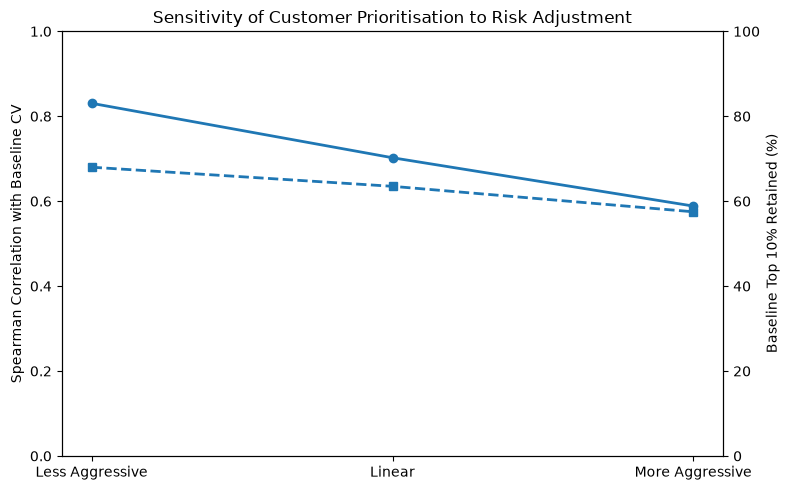

In [58]:
# --------------------------------------------------
# Sensitivity Analysis Figure
# --------------------------------------------------

sensitivity_plot = pd.DataFrame({
    "Adjustment": [
        "Less Aggressive",
        "Linear",
        "More Aggressive"
    ],
    "Spearman Correlation": [
        0.8305,
        0.7023,
        0.5885
    ],
    "Top 10% Overlap": [
        68.0,
        63.5,
        57.5
    ]
})

fig, ax1 = plt.subplots(figsize=(8, 5))

x = np.arange(len(sensitivity_plot))

ax1.plot(
    x,
    sensitivity_plot["Spearman Correlation"],
    marker="o",
    linewidth=2
)

ax1.set_ylabel("Spearman Correlation with Baseline CV")
ax1.set_ylim(0, 1)
ax1.set_xticks(x)
ax1.set_xticklabels(sensitivity_plot["Adjustment"])

ax2 = ax1.twinx()

ax2.plot(
    x,
    sensitivity_plot["Top 10% Overlap"],
    marker="s",
    linestyle="--",
    linewidth=2
)

ax2.set_ylabel("Baseline Top 10% Retained (%)")
ax2.set_ylim(0, 100)

plt.title("Sensitivity of Customer Prioritisation to Risk Adjustment")

fig.tight_layout()

plt.savefig(
    "../outputs/figures/risk_adjustment_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()